# **Анализ оттока клиентов (Customer Churn) в телеком-компании**

## Описание проекта

Отток клиентов (churn) является одной из ключевых проблем для телеком-компаний, так как напрямую влияет на выручку и устойчивость бизнеса. Удержание существующих клиентов, как правило, обходится дешевле, чем привлечение новых, поэтому задача анализа и прогнозирования оттока имеет высокую практическую значимость.

В данном проекте проводится комплексный разведочный анализ данных (EDA) для выявления факторов, влияющих на уход клиентов. Анализ охватывает как базовые, так и продвинутые методы исследования данных, позволяющие глубоко понять структуру и особенности датасета.


---

## Используемые методы анализа данных (EDA)

В рамках проекта применяются следующие методы:

### Первичный анализ и предобработка
- Загрузка данных и первичный обзор структуры
- Обработка скрытых пропусков
- Удаление неинформативных признаков
- Проверка на дубликаты

### Анализ целевой переменной
- Исследование распределения churn
- Оценка дисбаланса классов

### Одномерный анализ (Univariate Analysis)
- Анализ распределения числовых признаков
- Анализ категориальных признаков

### Двумерный анализ (Bivariate Analysis)
- Исследование зависимости признаков от целевой переменной
- Сравнение распределений между группами

### Многомерный анализ (Multivariate Analysis)
- Группировки и агрегирование признаков
- Визуализация взаимосвязей (pairplot)

### Корреляционный анализ
- Построение матрицы корреляций
- Выявление зависимостей между числовыми признаками

### Анализ выбросов и распределений
- Обнаружение выбросов (IQR, Z-score)
- Анализ асимметрии распределений
- Применение логарифмических преобразований
- Проверка нормальности распределений

### Статистический анализ
- t-тест для сравнения групп
- критерий хи-квадрат для категориальных признаков

### Снижение размерности
- PCA для визуализации структуры данных

---

## Цели проекта

- Провести комплексный разведочный анализ данных
- Выявить ключевые факторы, влияющие на отток клиентов
- Проверить статистические гипотезы
- Определить наиболее значимые признаки

---

## Описание данных

В проекте используется датасет Telco Customer Churn, содержащий информацию о клиентах телеком-компании.

Основные характеристики:
- 7043 наблюдения
- 21 признак
- Смешанные типы данных (числовые и категориальные)
- Наличие скрытых пропусков
- Дисбаланс классов

Целевая переменная:
- **Churn** — факт ухода клиента (Yes / No)

### Импорты

In [1]:
import numpy as np
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, normaltest, shapiro
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

C:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Загрузка данных

In [2]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

  0%|                                               | 0.00/172k [00:00<?, ?B/s]

100%|████████████████████████████████████████| 172k/172k [00:00<00:00, 664kB/s]

100%|████████████████████████████████████████| 172k/172k [00:00<00:00, 662kB/s]

Extracting files...


Path to dataset files: C:\Users\andre\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
df = pd.read_csv(os.path.join(path,'WA_Fn-UseC_-Telco-Customer-Churn.csv'))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Посмотрим на данные

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
list(df.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


По результатам `df.info()` можно заметить одну подозрительную особенность.

Признак **TotalCharges** имеет тип `object` (строка), хотя по смыслу должен быть числовым (`float64`). Это указывает на наличие скрытых нечисловых значений — например, пустых строк или специальных символов.

В то же время:
- **MonthlyCharges** корректно представлен как `float64`
- **tenure** и **SeniorCitizen** имеют тип `int64`

Признак **customerID** является уникальным идентификатором клиента и не несет аналитической ценности, поэтому он будет удален.

---

Анализ функции `describe()` позволяет получить общее представление о числовых признаках.

На данном этапе оцениваются:
- диапазоны значений признаков
- наличие потенциальных выбросов (через сравнение квартилей и максимальных значений)
- форма распределения (сравнение среднего и медианы)

Эти наблюдения помогают определить дальнейшие шаги предобработки данных, включая необходимость масштабирования или преобразования признаков.

### Предобработка данных

#### Шаг 1: Обработка признака TotalCharges

Признак **TotalCharges** по смыслу является числовым, однако в исходных данных он хранится в формате строк (`object`). Это указывает на наличие некорректных или скрытых значений, которые мешают корректной интерпретации признака.

На данном этапе необходимо разобраться, какие именно значения приводят к такой проблеме и привести столбец к числовому типу.

In [8]:
mask = pd.to_numeric(df['TotalCharges'], errors='coerce').isna()
print("Number of bad rows:", mask.sum())
print()
df[mask]

Number of bad rows: 11



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


В данных обнаружено 11 строк, где признак **TotalCharges** содержит пустое значение (пробел `" "`), вместо числового значения.

При анализе этих записей видно, что у всех клиентов значение **tenure = 0**. Это означает, что данные клиенты являются новыми пользователями, которые только что подключились к сервису. В их случае отсутствие начислений логично, так как биллинг ещё не производился.

Таким образом, проблема имеет бизнес-обоснованное объяснение, а не является ошибкой данных.

Существует два возможных подхода к обработке:
- удалить эти строки (незначительная доля — около 0.15% от всего датасета)
- заменить значения на 0, так как клиенты фактически ещё не имеют начислений

С точки зрения предметной области более корректным решением является заполнение значением 0, поскольку клиент с нулевым сроком обслуживания действительно не имеет накопленных расходов.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Missing values:", df['TotalCharges'].isna().sum())

TotalCharges dtype: float64
Missing values: 0


#### Шаг 2: Удаление customerID

Признак **customerID** является уникальным идентификатором каждого клиента. Он не содержит никакой информации о поведении пользователя и не имеет связи с целевой переменной **Churn**.

Поскольку каждое значение в этом столбце уникально, модель не может извлечь из него закономерности - наоборот, его наличие может добавить шум и ухудшить качество обучения.

Поэтому данный признак удаляется как неинформативный.

In [10]:
df = df.drop('customerID', axis=1)
print("Shape after dropping customerID:", df.shape)

Shape after dropping customerID: (7043, 20)


#### Шаг 3: Проверка оставшихся пропущенных значений

После первичной предобработки данных необходимо проверить датасет на наличие оставшихся пропущенных значений.

Это важно, так как пропуски могут:
- исказить статистические выводы на этапе EDA
- повлиять на качество обучения моделей машинного обучения
- привести к некорректной интерпретации зависимостей между признаками

На данном этапе выполняется финальная проверка качества данных перед дальнейшим анализом.

In [11]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing:", df.isnull().sum().sum())

Missing values per column:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


После предобработки данных пропущенные значения в датасете отсутствуют. Данные приведены к корректному виду и готовы к дальнейшему анализу.

---

## Важное наблюдение

Пропущенные значения не всегда представлены как `NaN`. На практике они могут скрываться в различных формах: пустые строки, пробелы, символы вроде `?` или `-`, а иногда даже как нулевые значения.

Поэтому использование только `isnull()` недостаточно для полноценной проверки качества данных. Рекомендуется дополнительно анализировать уникальные значения в признаках и их распределение.

### Дубликаты

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


Дубликаты в датасете отсутствуют.

Если бы они были обнаружены, их можно было бы удалить с помощью `df.drop_duplicates()`, так как дублирующиеся записи не добавляют новой информации и могут смещать анализ, искусственно усиливая влияние повторяющихся наблюдений.

Однако важно учитывать контекст данных. В некоторых случаях дубликаты могут быть допустимыми, например, если каждая строка представляет отдельное событие во времени (транзакции, логи, действия пользователей). В таких ситуациях удаление дубликатов может привести к потере корректной информации.

### Определение типов признаков

Перед началом разведочного анализа данных важно разделить признаки на числовые и категориальные.

Это позволяет упростить дальнейший анализ: автоматизировать построение визуализаций, применять корректные статистические методы и отдельно рассматривать поведение разных типов переменных.

На данном этапе выполняется классификация столбцов по типам данных.

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = [c for c in cat_cols if c != 'Churn']

print("Categorical features:", cat_cols)
print("Count:", len(cat_cols))
print()
print("Numeric features:", num_cols)
print("Count:", len(num_cols))

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Count: 16

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Count: 3


Признак **SeniorCitizen** изначально закодирован значениями 0 и 1, однако по смыслу он является категориальной бинарной переменной (да/нет), а не числовым признаком.

Если оставить его в числовом формате, некоторые модели могут интерпретировать его как количественную переменную, где значение 1 «больше» 0 в математическом смысле, что не отражает реальной природы признака.

Поэтому для более корректной интерпретации данных его целесообразно рассматривать как категориальный признак.

---

В зависимости от используемой модели подход может различаться:
- для деревьев решений и ансамблевых моделей (например, Random Forest) такое кодирование обычно не критично
- для линейных моделей (например, логистической регрессии) важно корректно интерпретировать бинарные признаки как категориальные, особенно если требуется строгая интерпретация коэффициентов

## Распределение целевой переменной (проверка дисбаланса)

Анализ целевой переменной — первый шаг в любом EDA.

На данном этапе оценивается, сбалансированы ли классы или присутствует дисбаланс.

Target value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target proportions:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


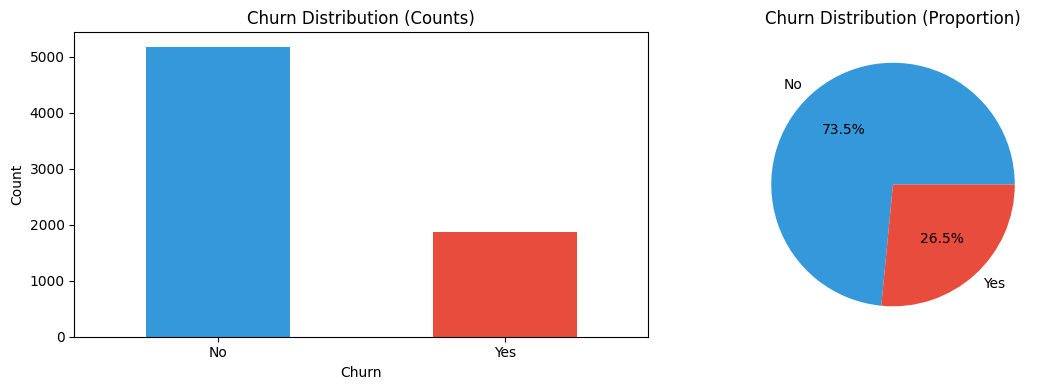


Imbalance ratio: 2.77:1


In [14]:
print("Target value counts:")
print(df['Churn'].value_counts())
print()
print("Target proportions:")
print(df['Churn'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Churn Distribution (Counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#3498db', '#e74c3c'])
axes[1].set_ylabel('')
axes[1].set_title('Churn Distribution (Proportion)')

plt.tight_layout()
plt.show()

majority = df['Churn'].value_counts().max()
minority = df['Churn'].value_counts().min()
print(f"\nImbalance ratio: {majority/minority:.2f}:1")

Около 73% клиентов не покинули сервис, и 27% клиентов ушли. Таким образом, наблюдается дисбаланс классов с соотношением примерно 2.7:1.

Это умеренный уровень дисбаланса. Он не является критическим, однако может влиять на качество моделей, особенно если в качестве основной метрики использовать accuracy.

Например, модель, которая всегда предсказывает класс "No Churn", будет показывать около 73% accuracy, не извлекая при этом никакой полезной информации.

## Одномерный анализ (Univariate Analysis)

Анализ одного признака за раз. Цель — понять распределение каждой отдельной переменной до изучения взаимосвязей между ними.

Этот этап отвечает на вопрос: *как выглядит каждый признак сам по себе?*

---

### Числовые признаки

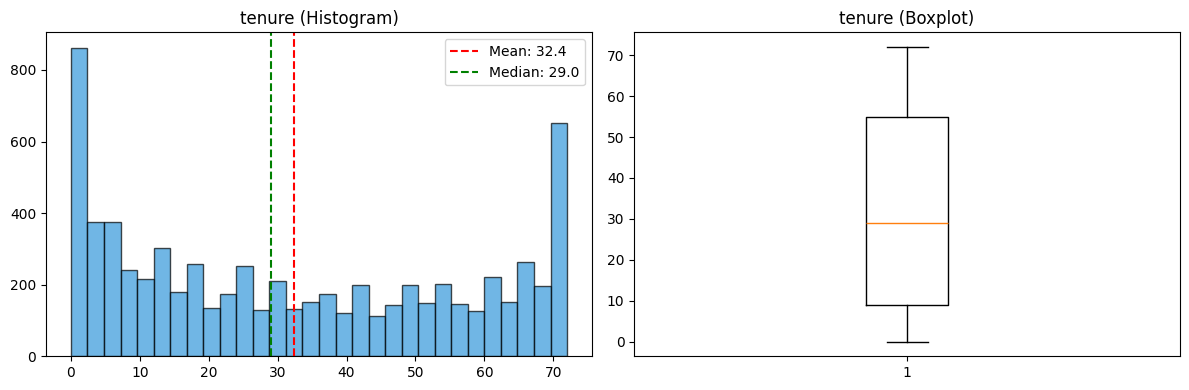

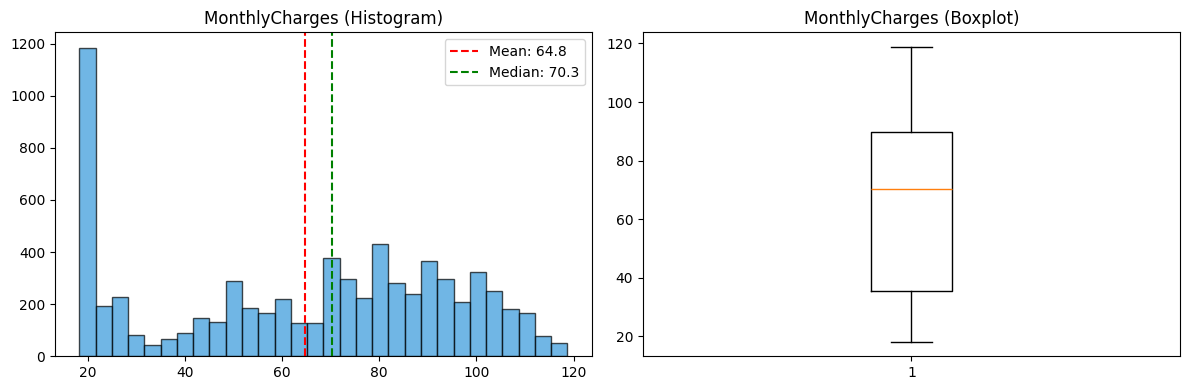

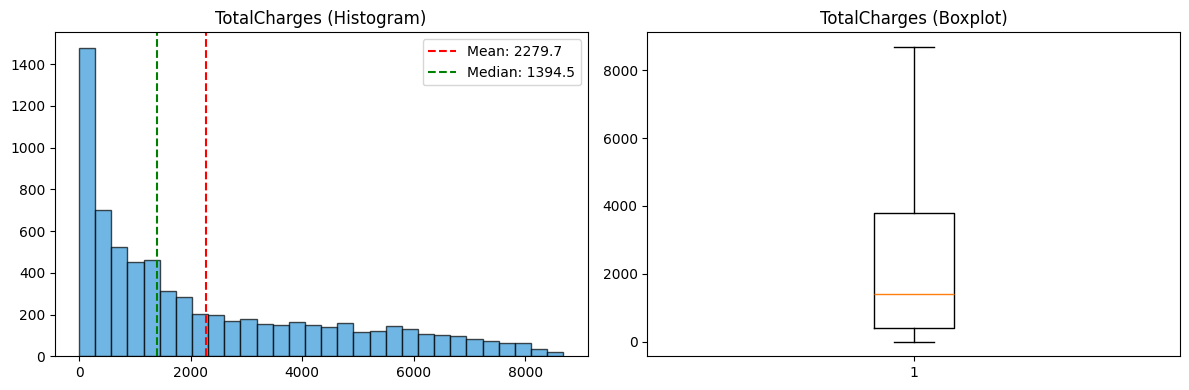

In [15]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[0].set_title(f'{col} (Histogram)')
    axes[0].legend()

    axes[1].boxplot(df[col], vert=True)
    axes[1].set_title(f'{col} (Boxplot)')

    plt.tight_layout()
    plt.show()

In [16]:
print("Extended Statistics:")
print(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

Extended Statistics:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
1%        1.00           19.20         19.75
5%        1.00           19.65         48.60
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
95%      72.00          107.40       6921.02
99%      72.00          114.73       8039.26
max      72.00          118.75       8684.80


#### Наблюдения по графикам

**tenure**: наблюдается бимодальное распределение. Виден пик в диапазоне 0–5 месяцев (новые клиенты) и второй пик на уровне 70+ месяцев (долгосрочные клиенты). Клиентов со средним сроком использования относительно мало, что может указывать на две основные группы поведения: быстрый отток и долгосрочная лояльность.

**MonthlyCharges**: значения распределены по всему диапазону без выраженных выбросов. Распределение близко к равномерному.

**TotalCharges**: сильно скошено вправо. Большая часть клиентов имеет низкие суммарные начисления (новые клиенты), в то время как небольшая группа долгосрочных клиентов формирует высокий хвост распределения. Также присутствуют нулевые значения, соответствующие новым клиентам, ранее обработанные в предобработке.

---

| Условие | Интерпретация |
|---|---|
| mean > median | Правосторонняя асимметрия (длинный хвост вправо) |
| mean < median | Левосторонняя асимметрия (длинный хвост влево) |
| mean ≈ median | Примерно симметричное распределение |

---

### Категориальные признаки

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


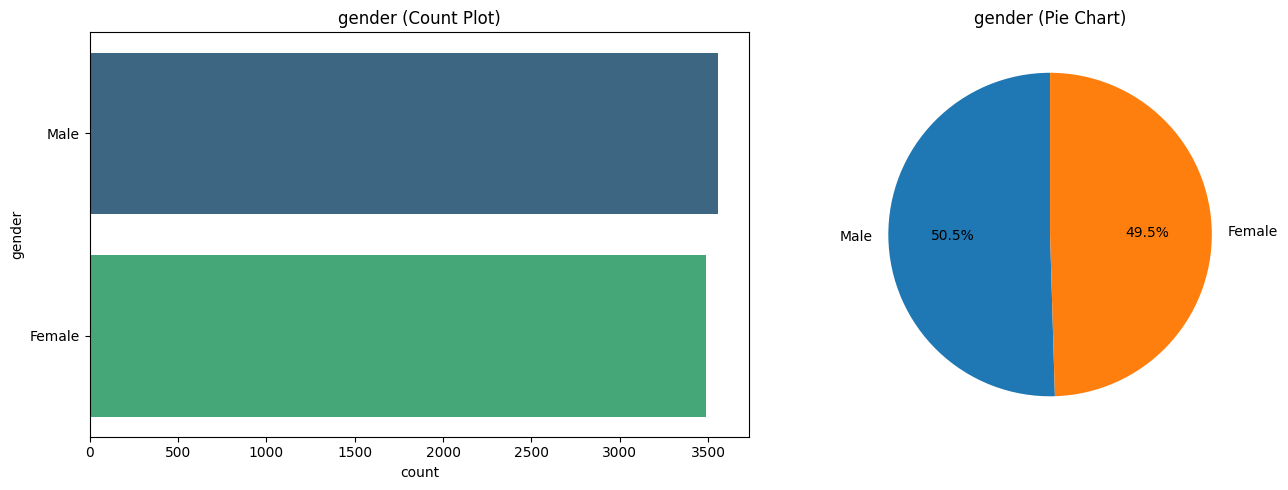

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


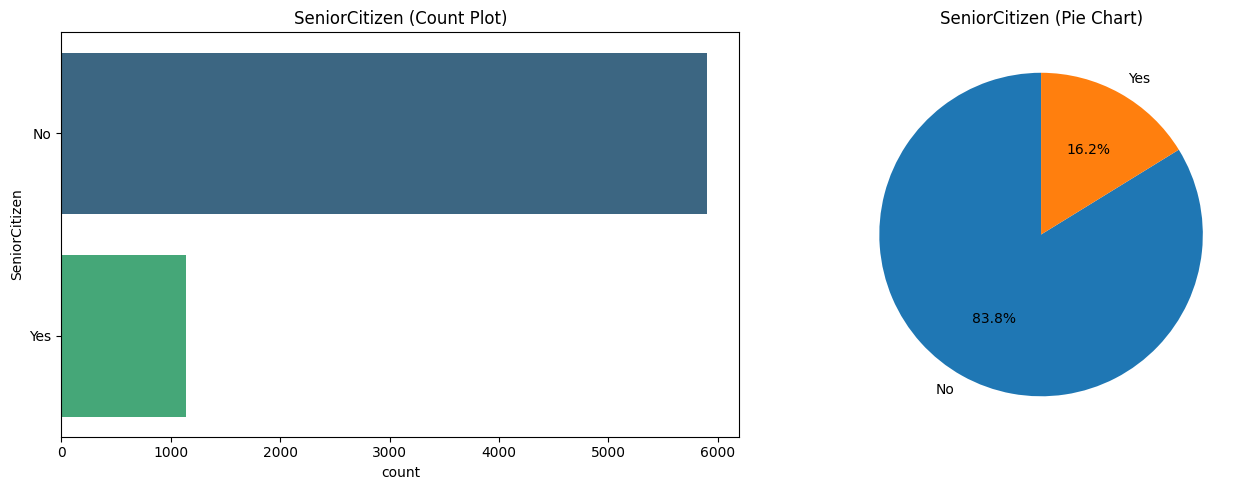

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


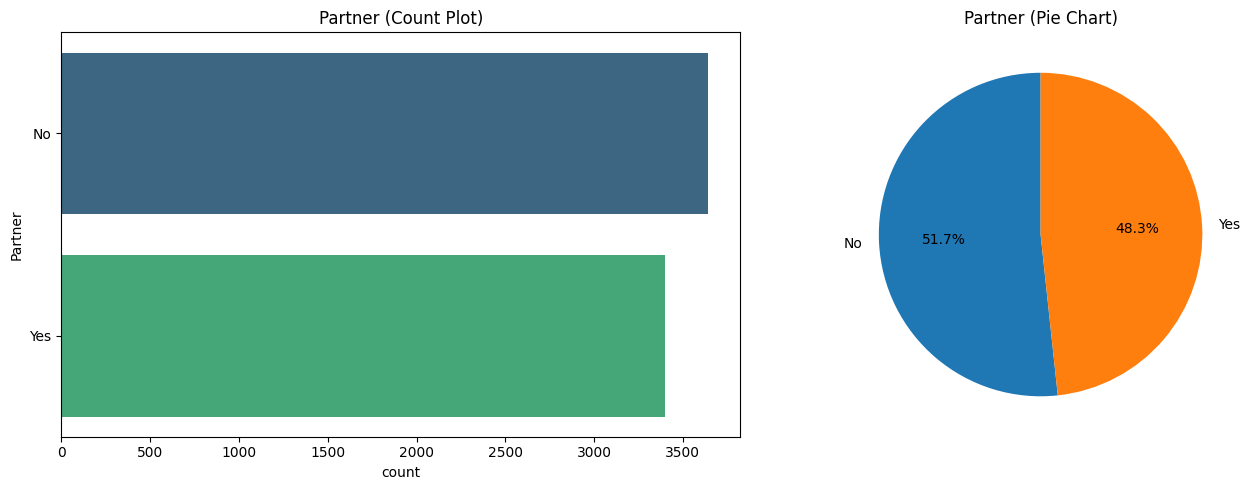

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


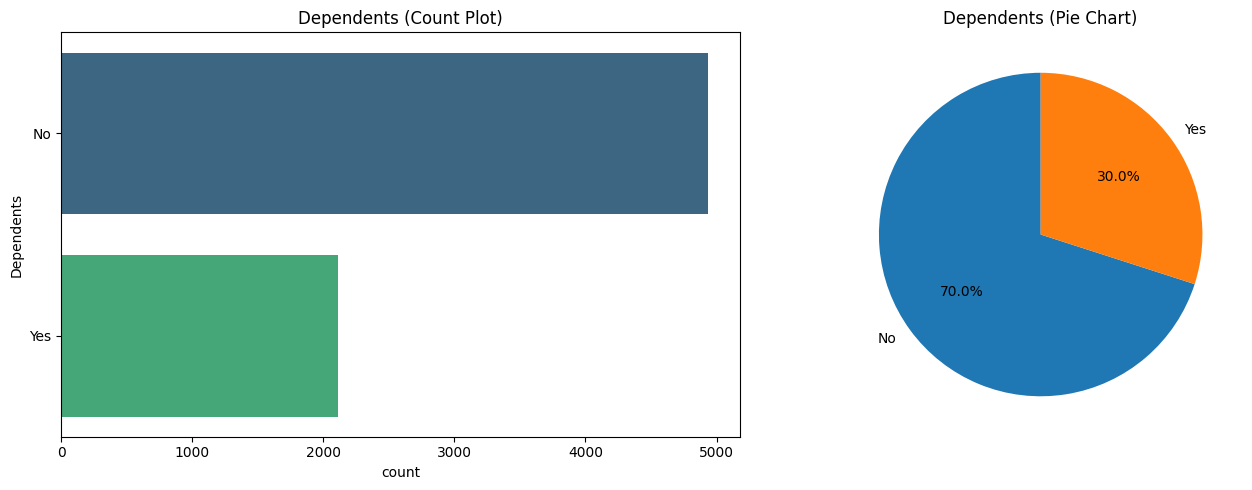

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


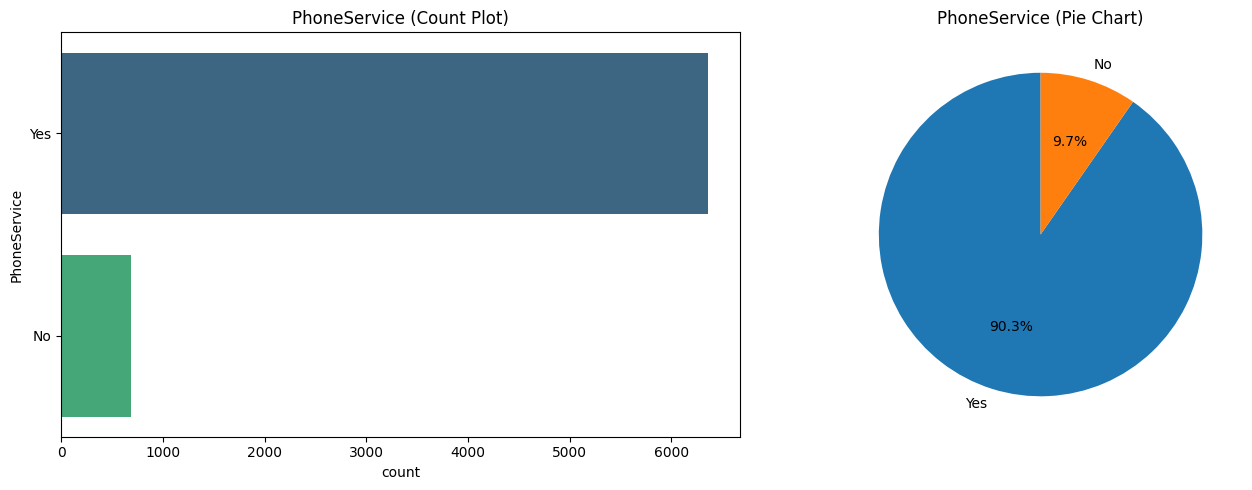

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


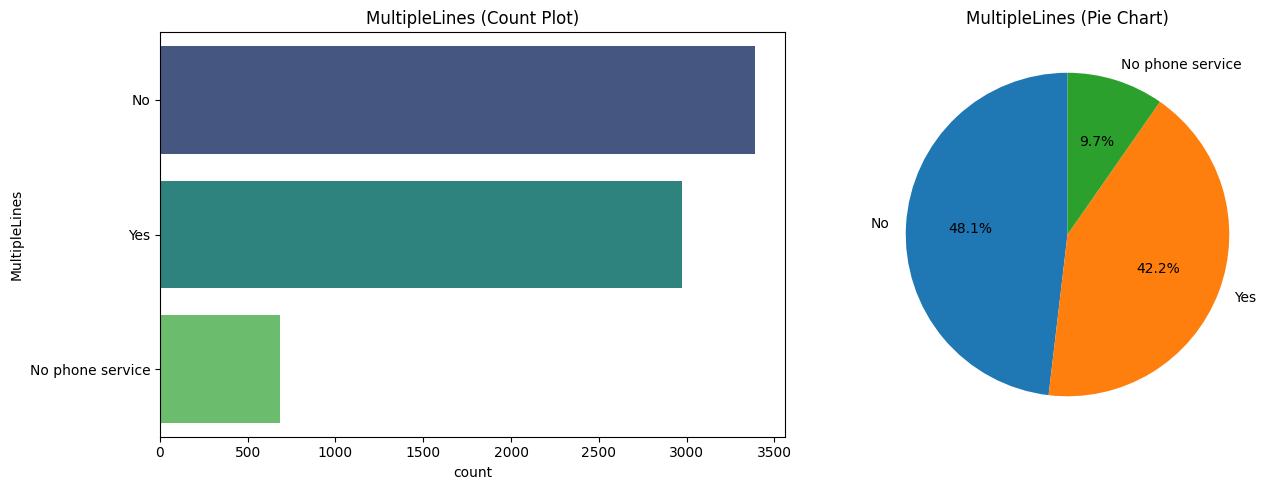

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


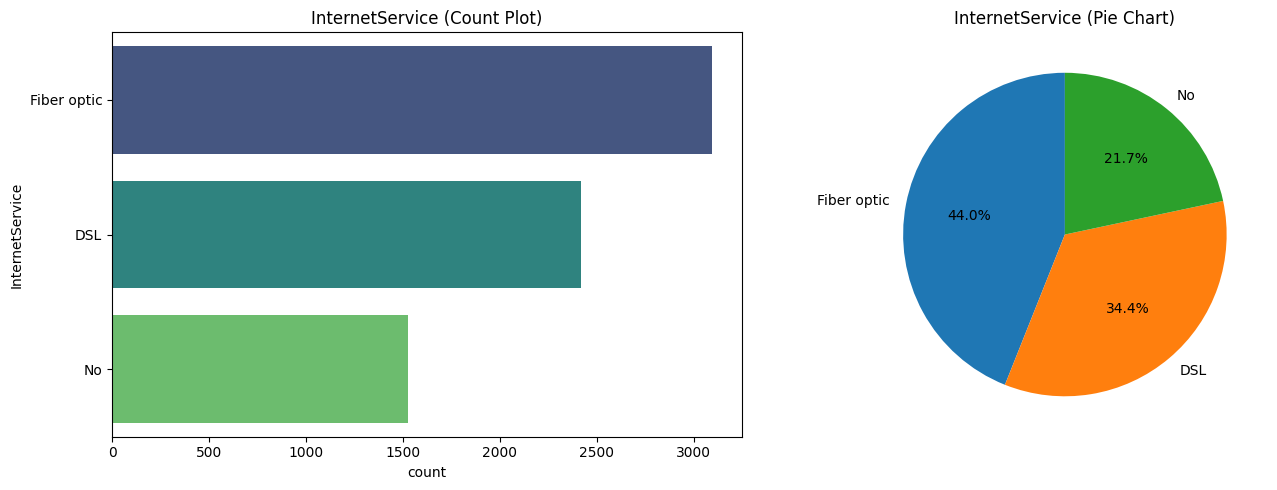

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


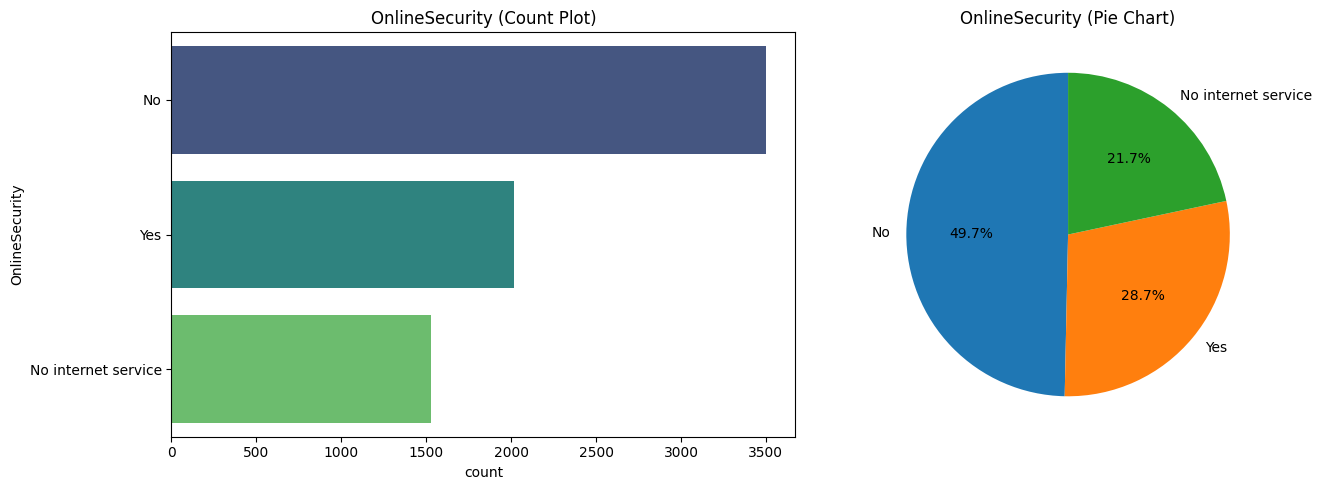

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


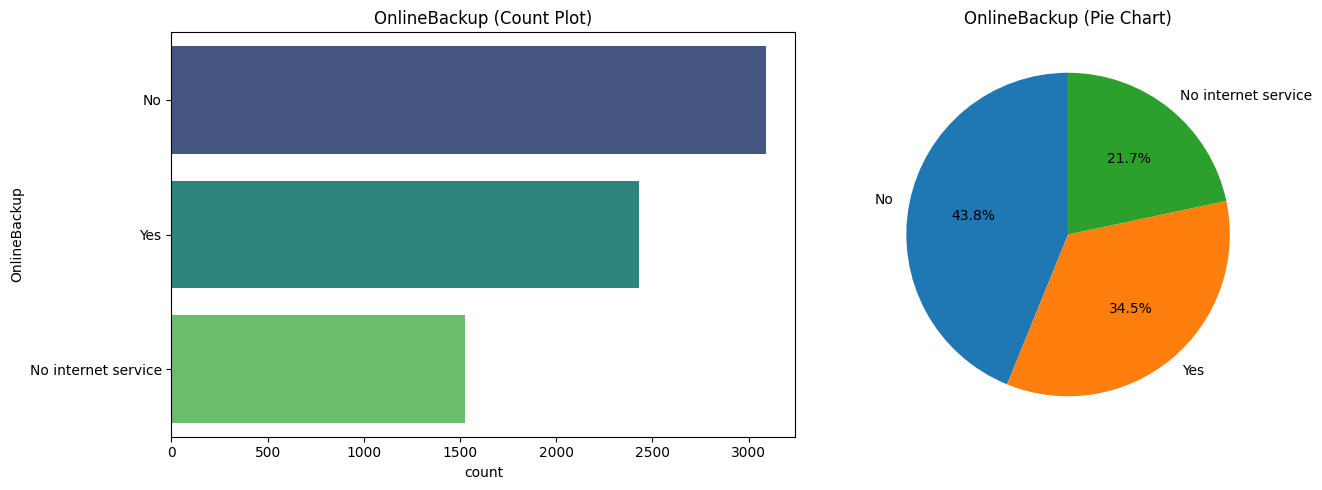

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


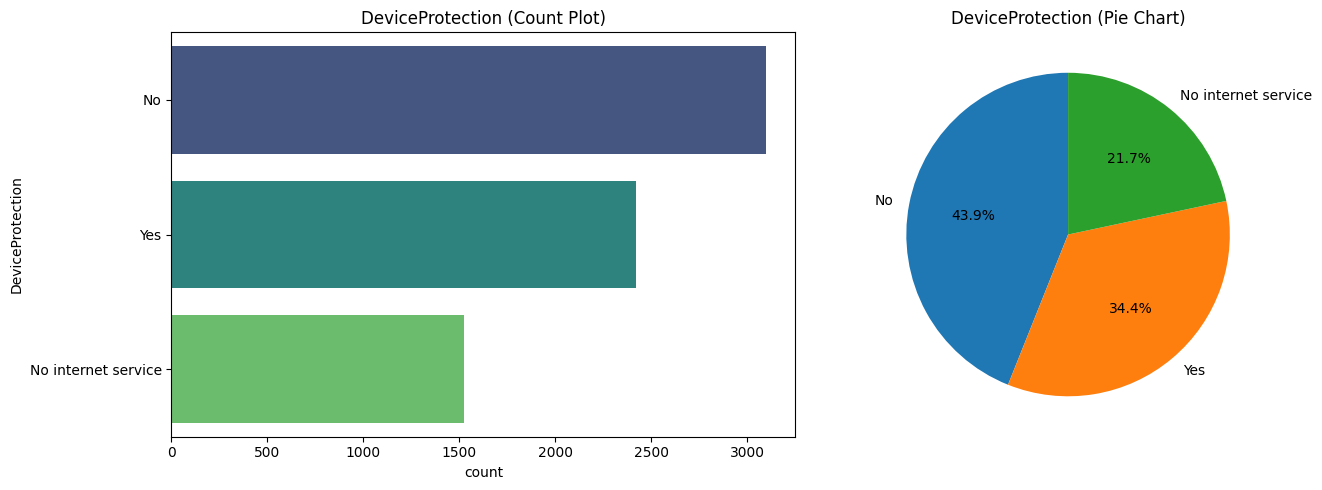

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


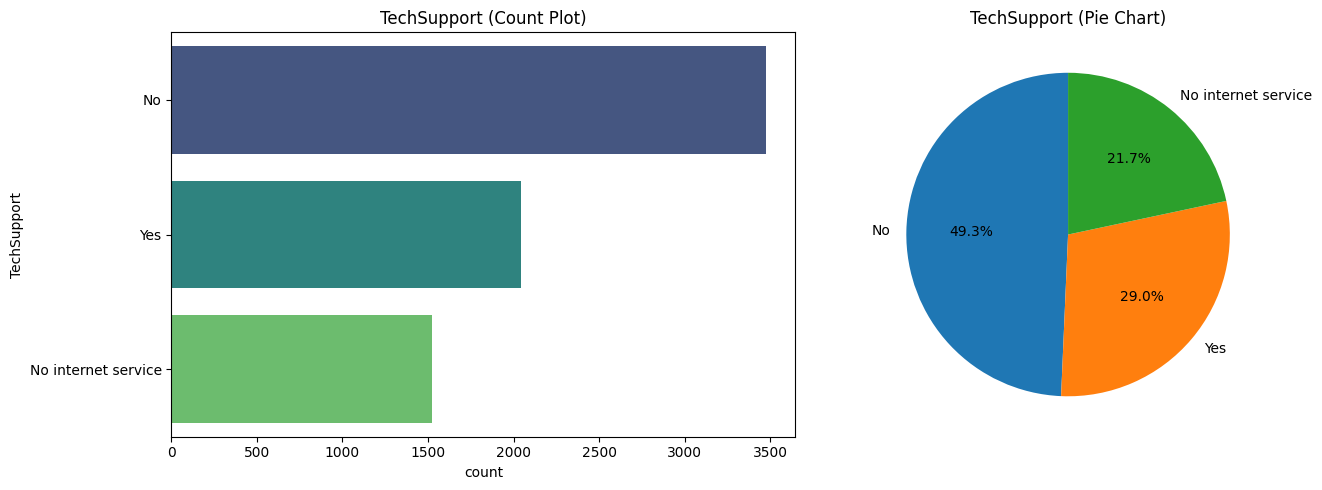

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


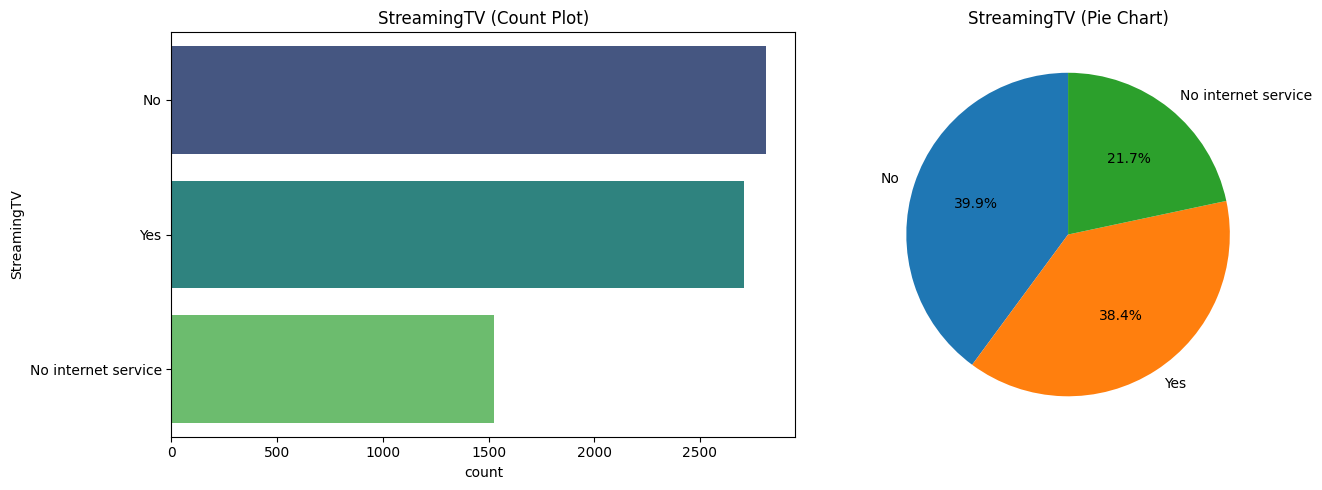

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


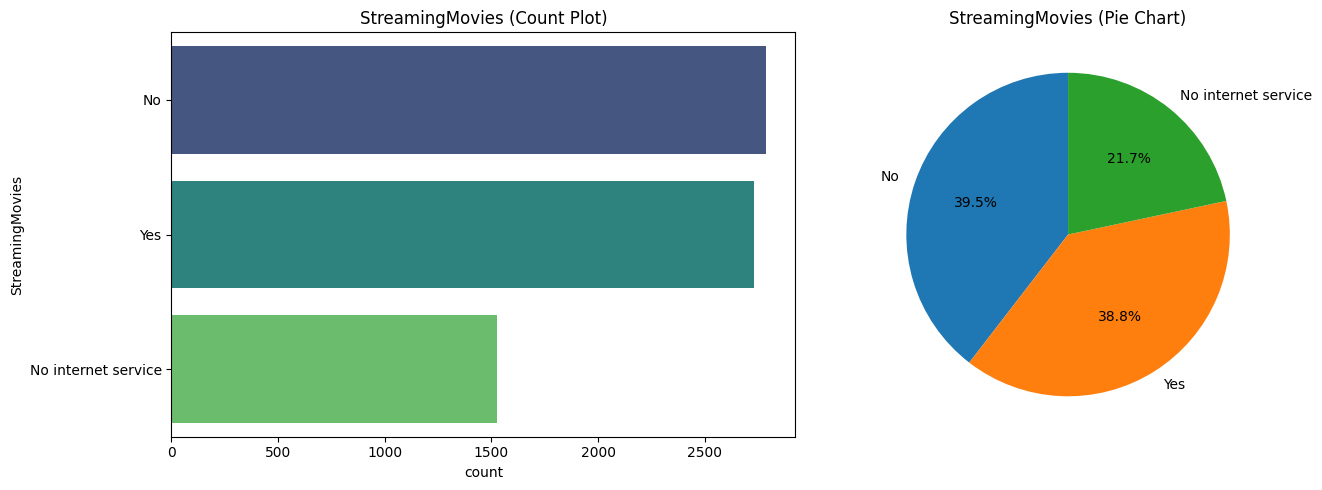

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


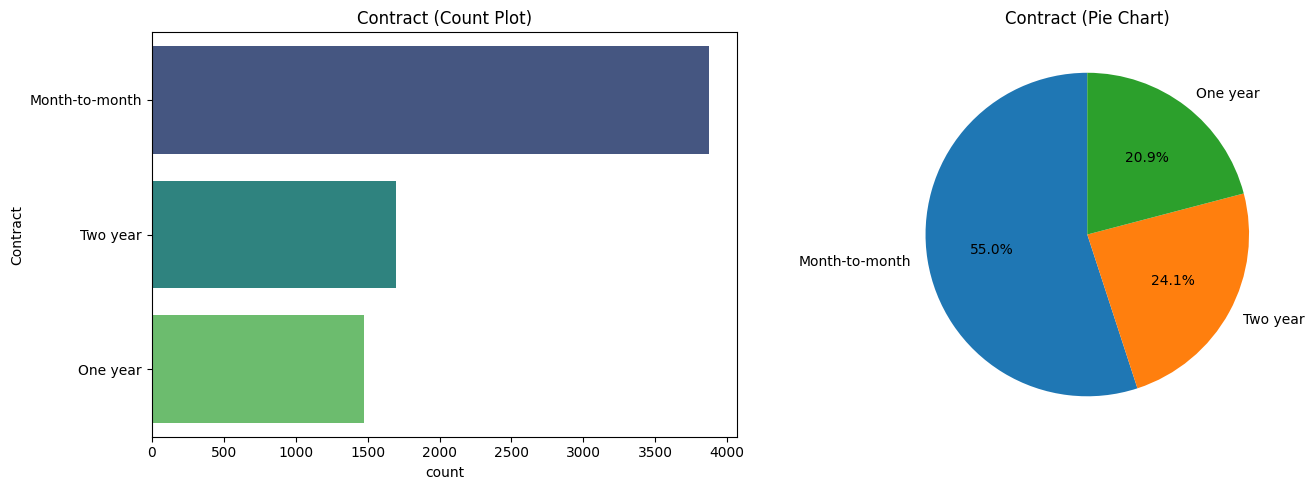

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


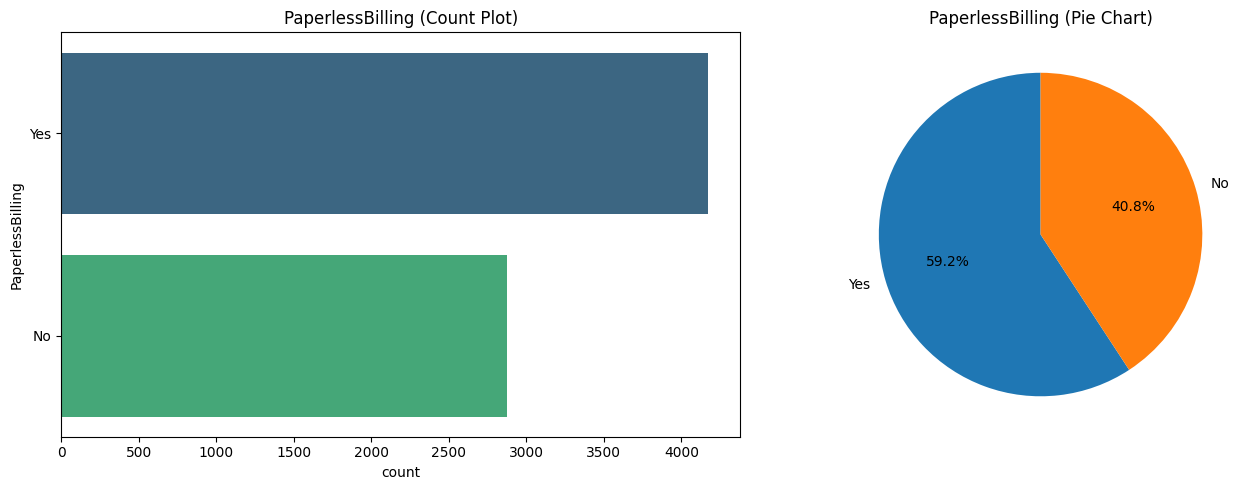

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\345223682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')


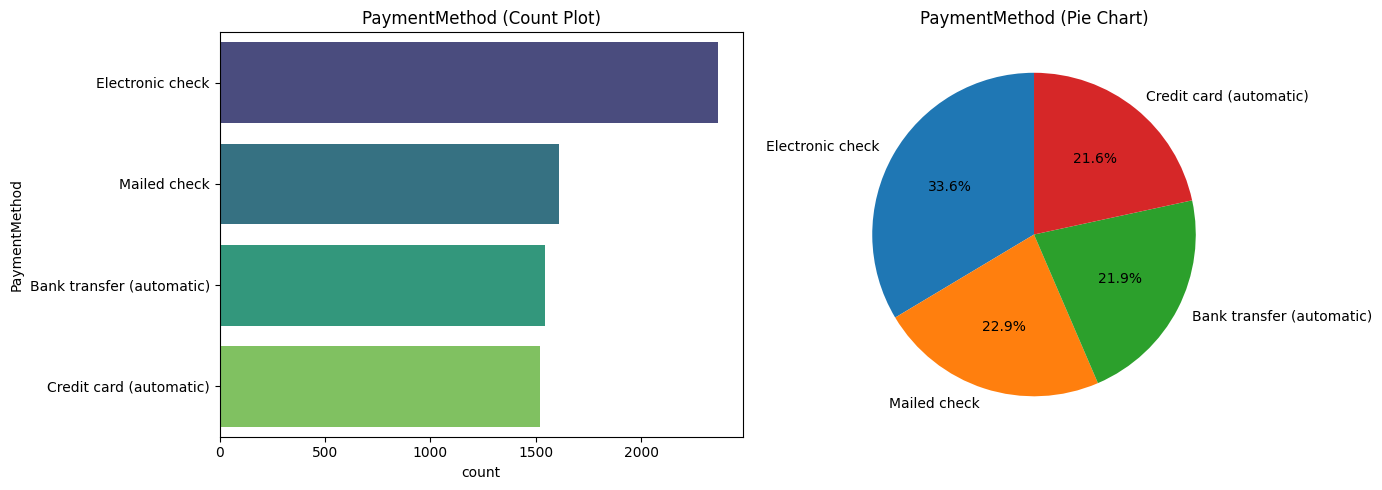

In [17]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[0], palette='viridis')
    axes[0].set_title(f'{col} (Count Plot)')

    counts = df[col].value_counts()
    if len(counts) > 8:
        top = counts.head(7)
        top['Other'] = counts.iloc[7:].sum()
        counts = top
    counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'{col} (Pie Chart)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

In [18]:
print("Cardinality of categorical features:")
print("-" * 35)
for col in cat_cols:
    print(f"  {col:20s}: {df[col].nunique()} unique values")

Cardinality of categorical features:
-----------------------------------
  gender              : 2 unique values
  SeniorCitizen       : 2 unique values
  Partner             : 2 unique values
  Dependents          : 2 unique values
  PhoneService        : 2 unique values
  MultipleLines       : 3 unique values
  InternetService     : 3 unique values
  OnlineSecurity      : 3 unique values
  OnlineBackup        : 3 unique values
  DeviceProtection    : 3 unique values
  TechSupport         : 3 unique values
  StreamingTV         : 3 unique values
  StreamingMovies     : 3 unique values
  Contract            : 3 unique values
  PaperlessBilling    : 2 unique values
  PaymentMethod       : 4 unique values


#### Наблюдения по категориальным признакам

- **gender**: распределение примерно равномерное (50/50). Слабая вариативность, скорее всего, низкая предсказательная ценность.

- **PhoneService**: большинство клиентов имеют подключённую услугу. Признак с низкой дисперсией.

- **InternetService**: представлено 3 категории, включая клиентов без интернет-сервиса. Это важное разбиение для дальнейшего анализа.

- **OnlineSecurity / OnlineBackup / TechSupport и др.**: присутствует категория *"No internet service"*, которая по сути дублирует ситуацию `InternetService = No`. Это потенциально избыточная информация, которую стоит учитывать при feature engineering.

- **Contract**: заметно, что большинство клиентов используют помесячный контракт. Это может быть одним из ключевых факторов оттока.

- **PaymentMethod**: распределение по 4 категориям относительно сбалансировано, без сильного перекоса.

---

### Кардинальность признаков

Кардинальность — это количество уникальных значений в категориальном признаке.

Она важна, так как напрямую влияет на выбор метода кодирования:
- низкая кардинальность (2–5 значений) → подходит One-Hot Encoding
- высокая кардинальность (десятки и сотни значений) → приводит к разрастанию пространства признаков

В случае высокой кардинальности обычно применяют:
- target encoding
- frequency encoding
- объединение редких категорий в класс *Other*

## Двумерный анализ (Bivariate Analysis)

Это один из ключевых этапов разведочного анализа данных.

На данном этапе рассматривается связь каждого признака с целевой переменной.

Основной вопрос:
*отличается ли поведение признака у клиентов, которые ушли, и у тех, кто остался?*

Если различия выражены — признак потенциально полезен для предсказания. Если нет — его информативность может быть низкой.

---

### Числовые признаки vs целевая переменная

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])


C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


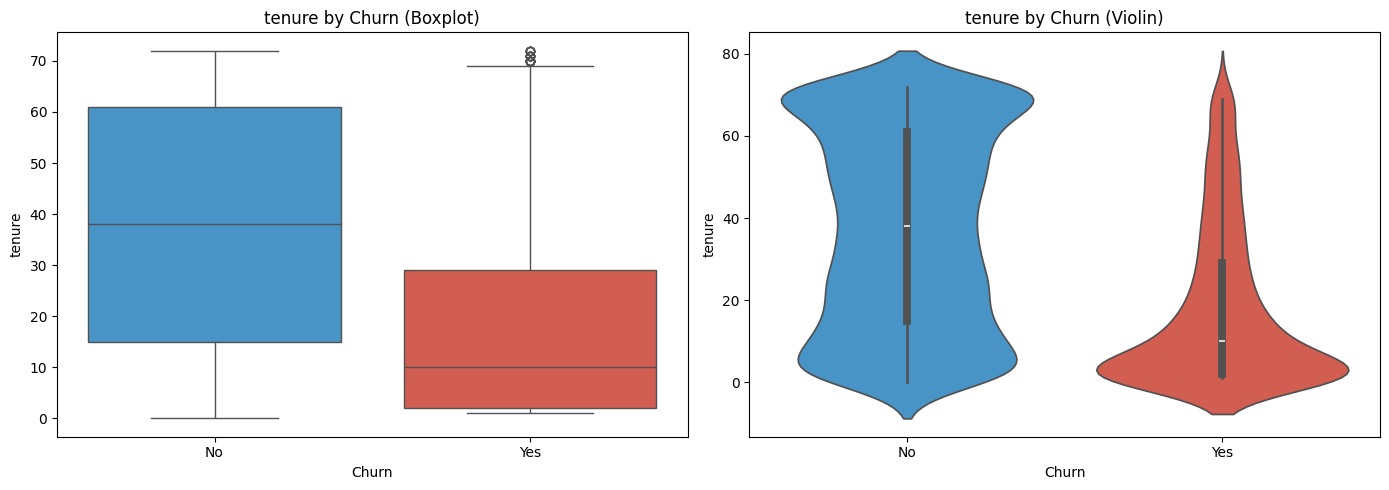

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


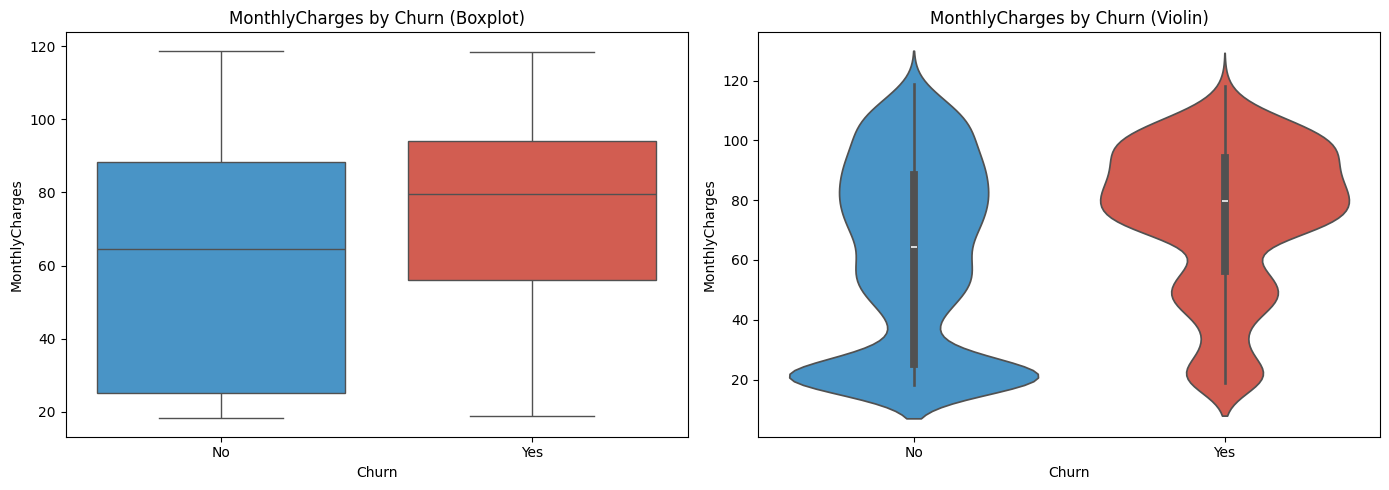

C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
C:\Users\andre\AppData\Local\Temp\ipykernel_17096\11429008.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])


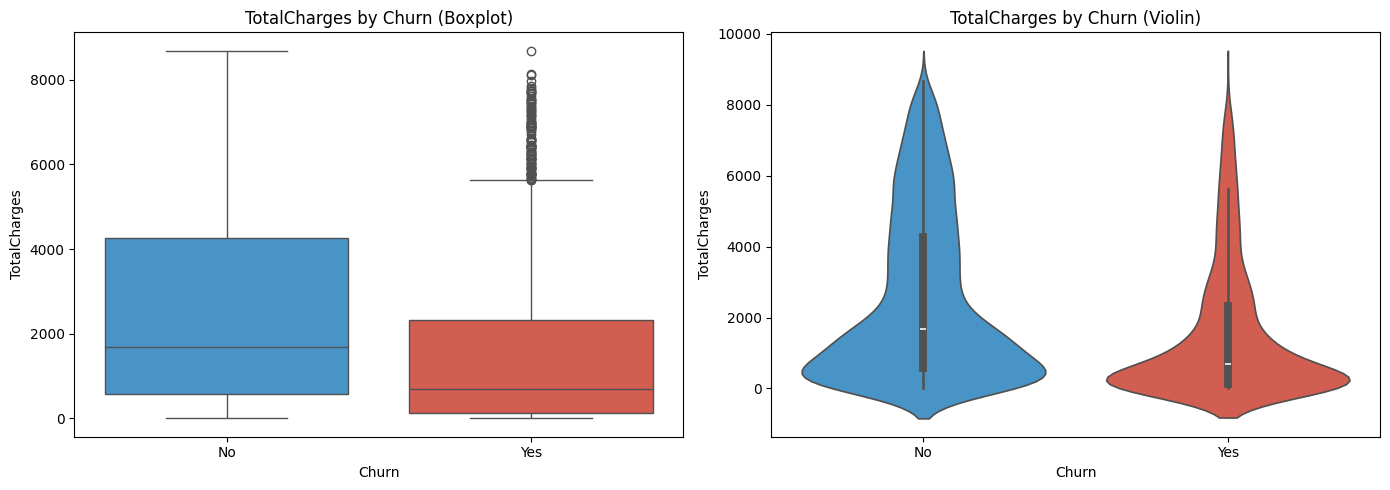

In [19]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df, x='Churn', y=col, ax=axes[0], palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} by Churn (Boxplot)')

    sns.violinplot(data=df, x='Churn', y=col, ax=axes[1], palette=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} by Churn (Violin)')

    plt.tight_layout()
    plt.show()

In [20]:
group_stats = df.groupby('Churn')[num_cols].mean()
group_stats = group_stats.T
group_stats.columns = ['No_Churn_Mean', 'Yes_Churn_Mean']
group_stats['Difference'] = group_stats['Yes_Churn_Mean'] - group_stats['No_Churn_Mean']
print("Mean values by Churn class:")
print(group_stats.round(2))

Mean values by Churn class:
                No_Churn_Mean  Yes_Churn_Mean  Difference
tenure                  37.57           17.98      -19.59
MonthlyCharges          61.27           74.44       13.18
TotalCharges          2549.91         1531.80    -1018.12


#### Основные закономерности

**tenure**: у клиентов, которые ушли, значительно ниже срок использования услуг (в среднем ~18 месяцев), чем у тех, кто остался (~38 месяцев). Это логично: новые клиенты чаще принимают решение об уходе, тогда как долгосрочные клиенты уже сформировали лояльность.

**MonthlyCharges**: ушедшие клиенты в среднем платят более высокую ежемесячную стоимость. Это может указывать на то, что пользователи дорогих тарифов чаще воспринимают услугу как недостаточно выгодную.

**TotalCharges**: у клиентов с churn ниже суммарные расходы, что напрямую связано с меньшим tenure — они уходят раньше и не успевают накопить большие суммы платежей.

---

#### Сравнение Boxplot и Violin Plot

| Тип графика | Что показывает | Когда использовать |
|---|---|---|
| Boxplot | медиану, квартильный размах, выбросы | быстрый сравнительный анализ распределений |
| Violin plot | полную форму распределения | анализ структуры распределения (асимметрия, мультимодальность) |

Если медианы групп заметно различаются и распределения слабо пересекаются, признак обладает высокой разделяющей способностью. Если распределения сильно перекрываются, самостоятельная предсказательная сила признака ограничена.

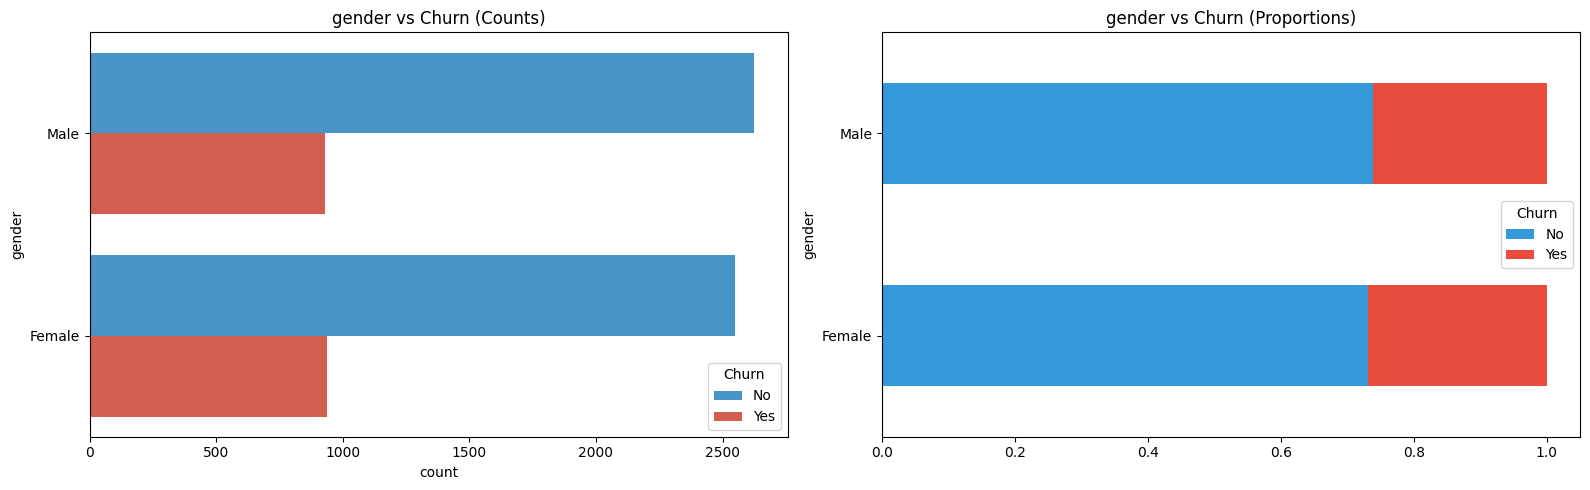

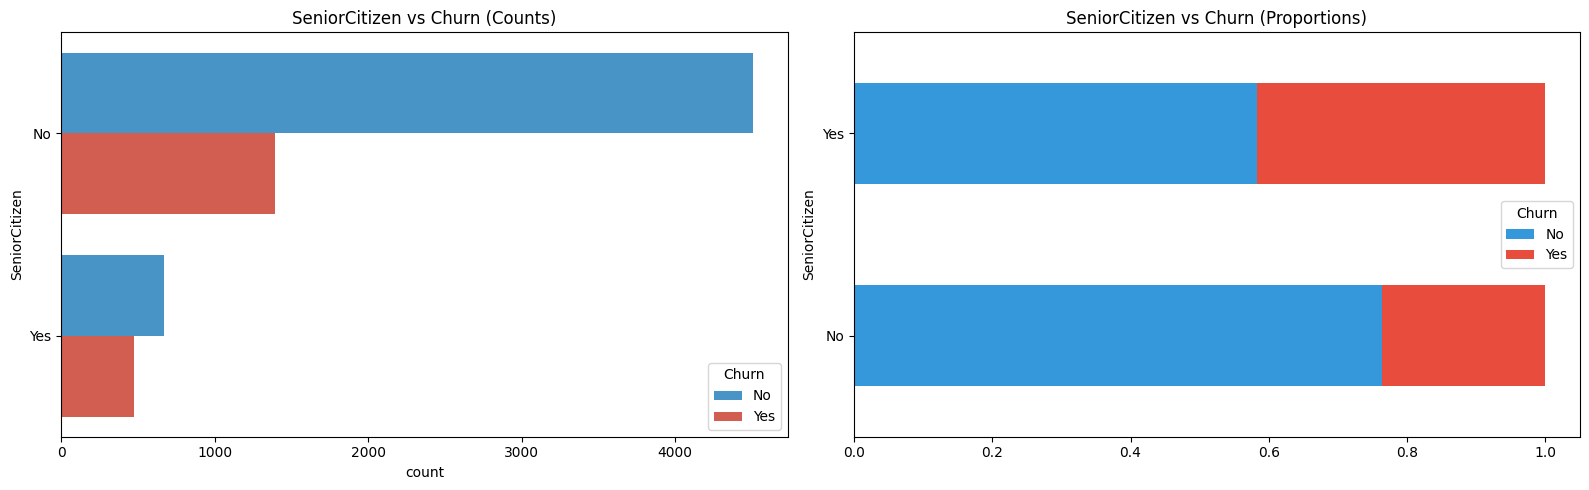

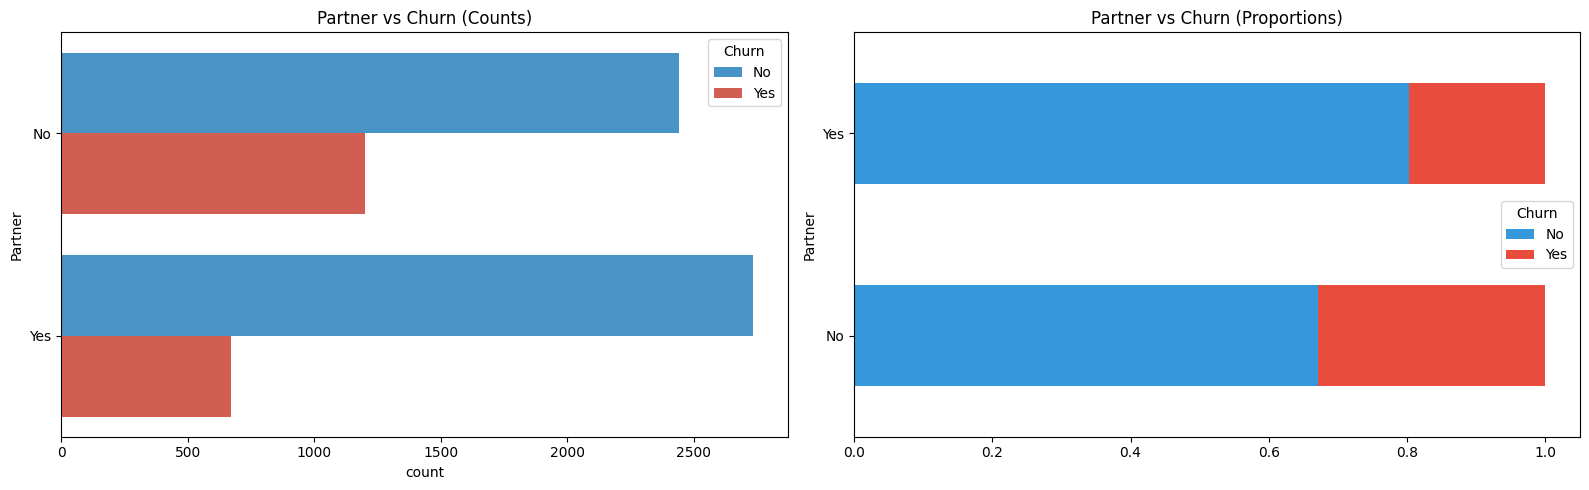

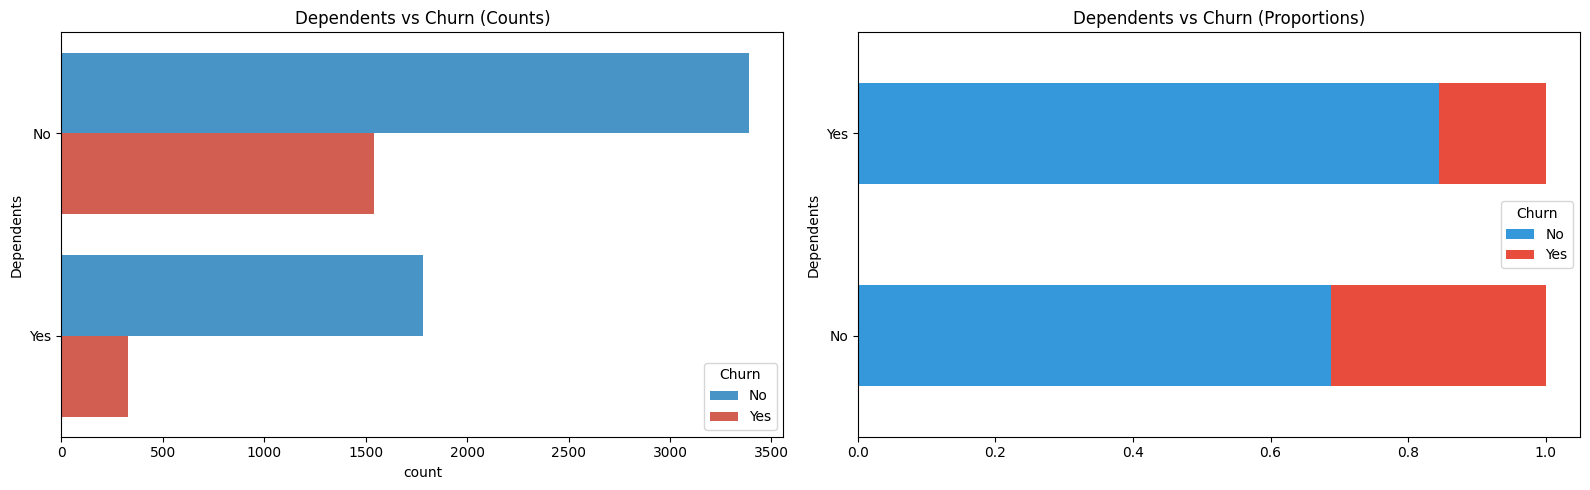

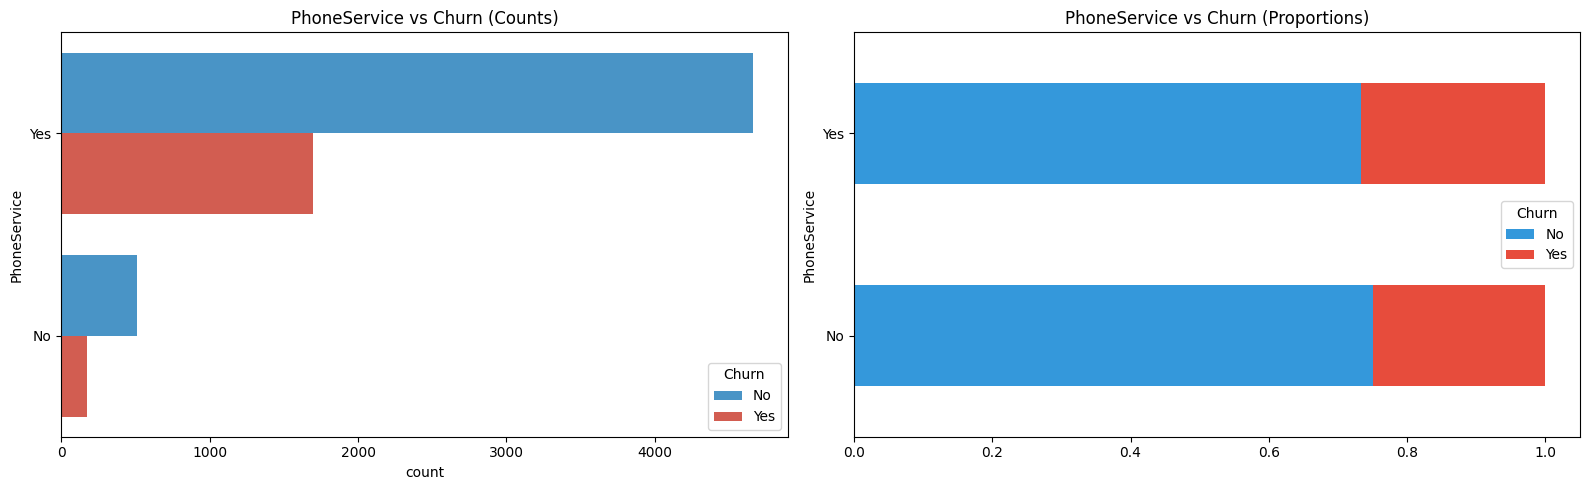

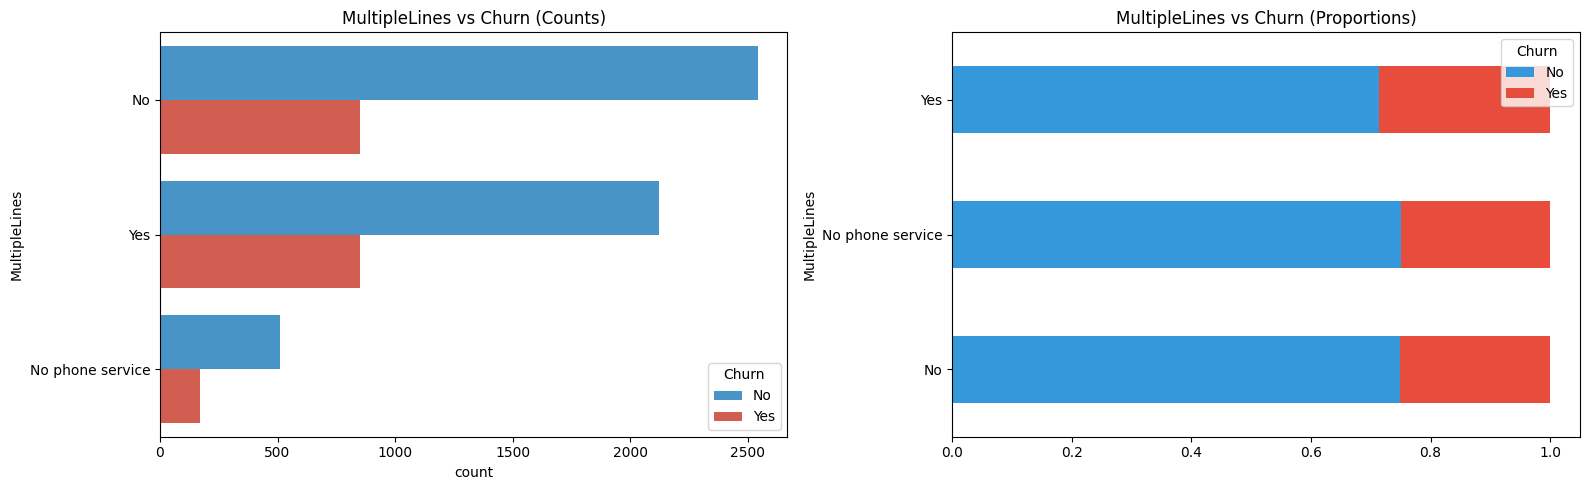

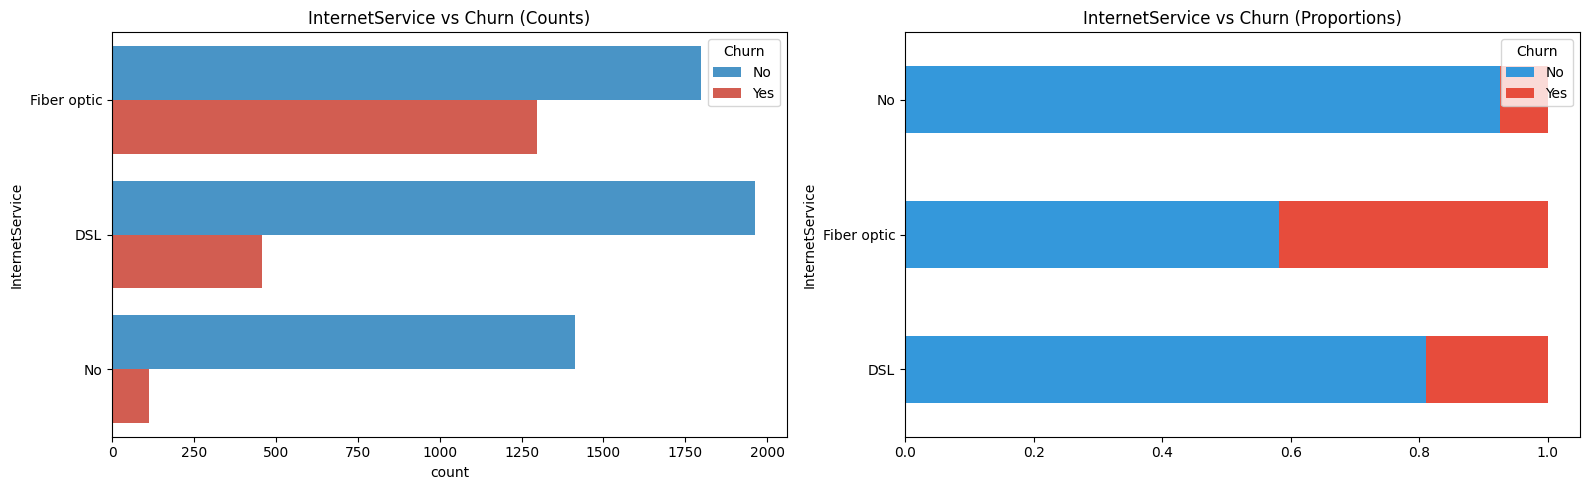

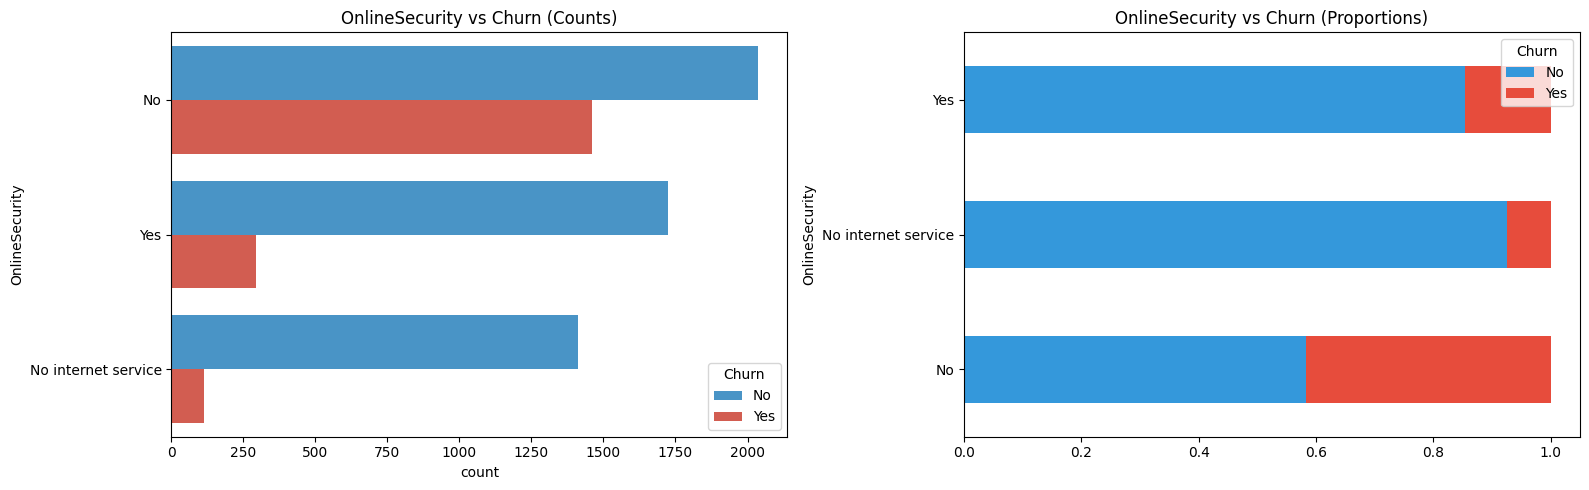

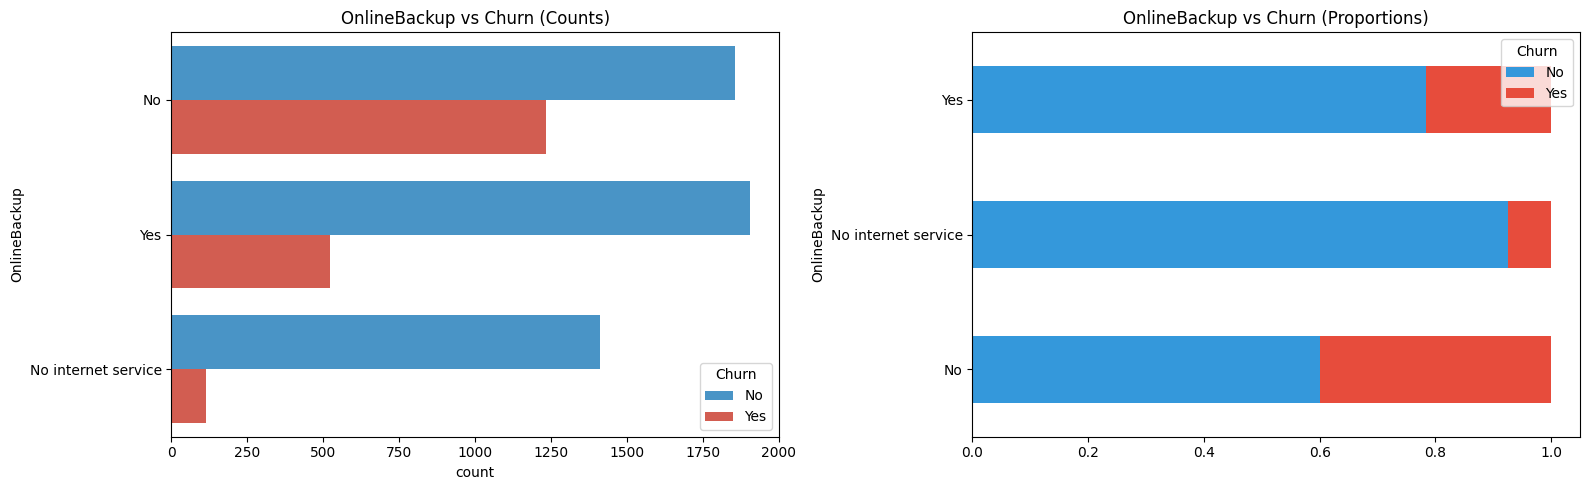

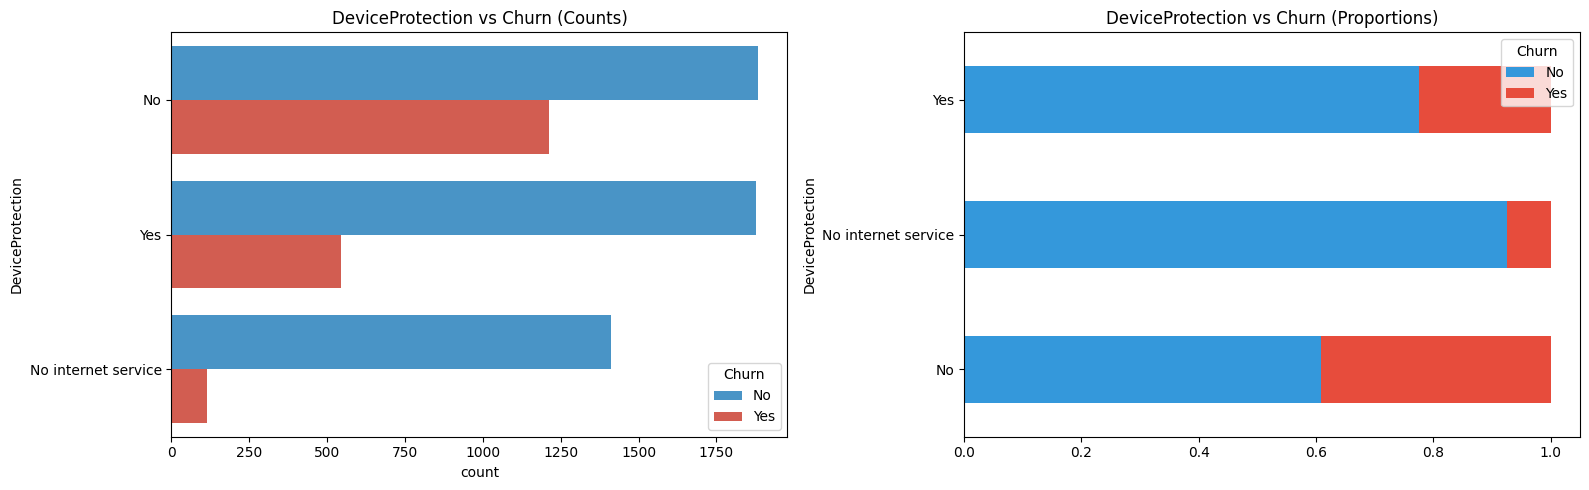

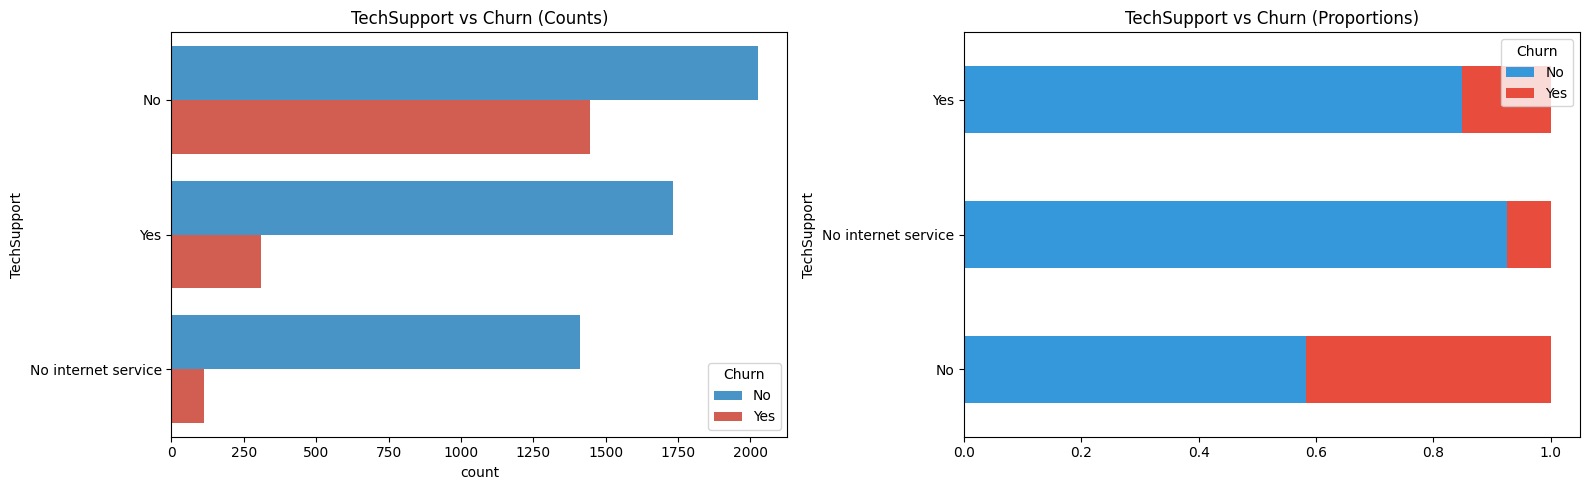

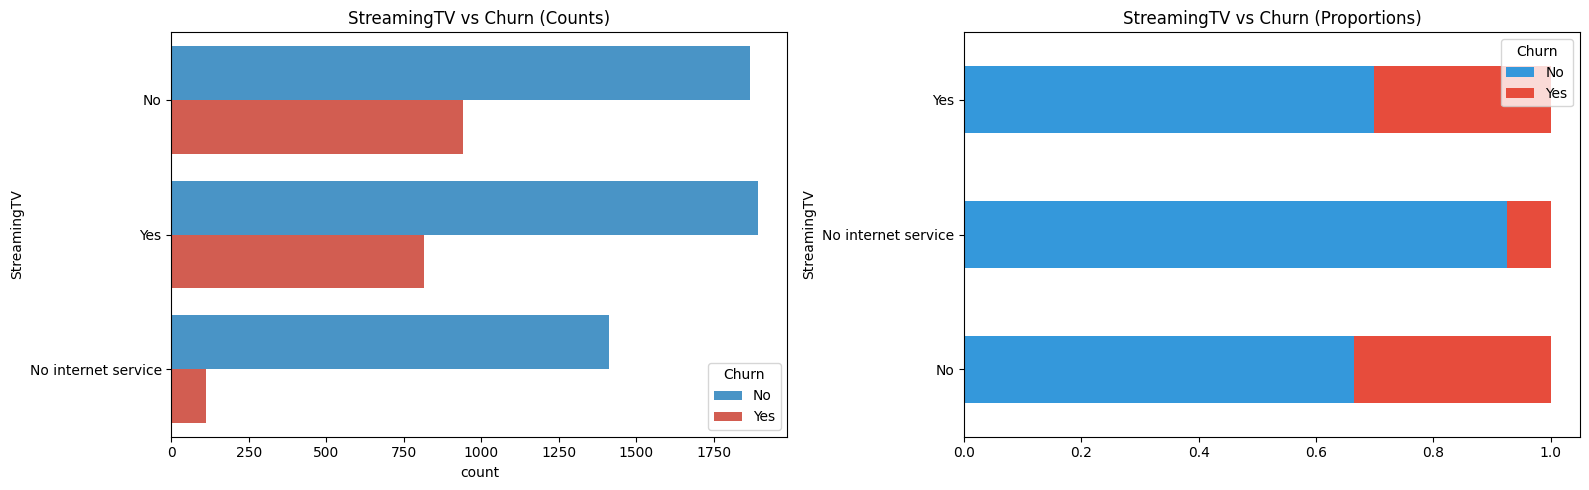

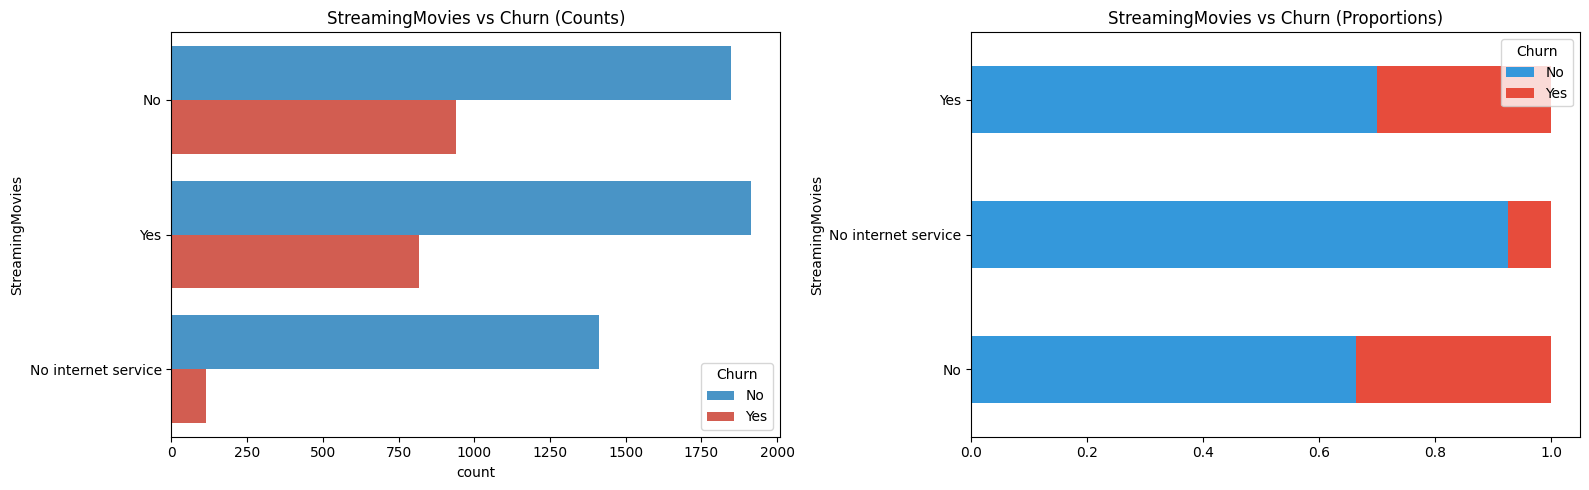

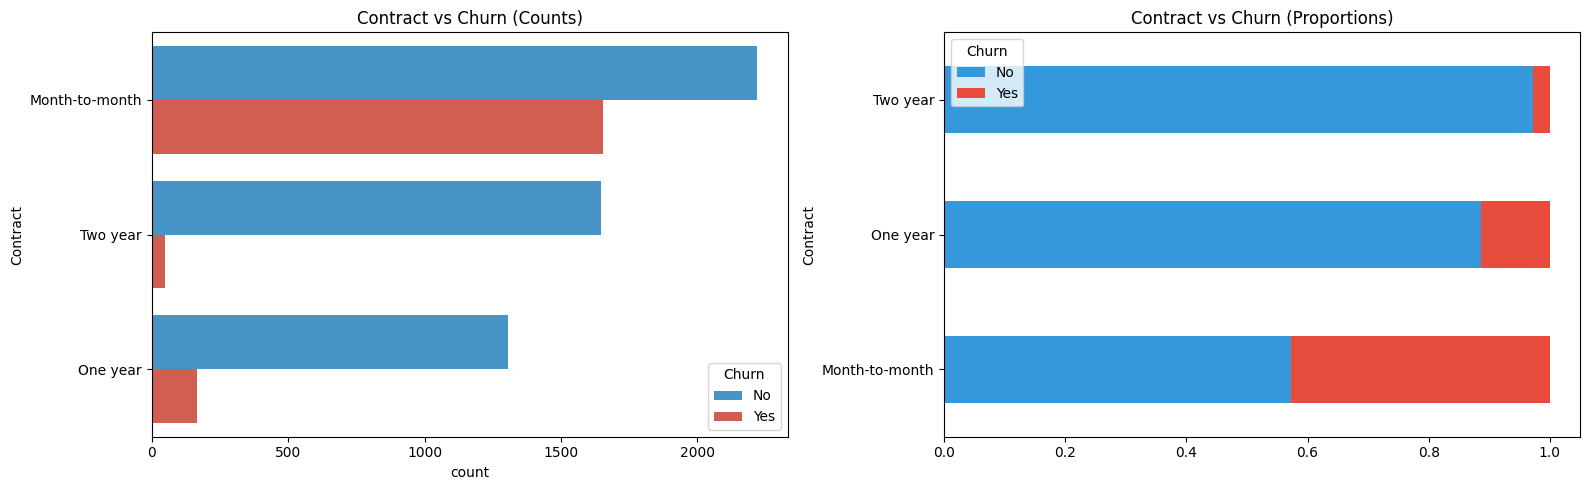

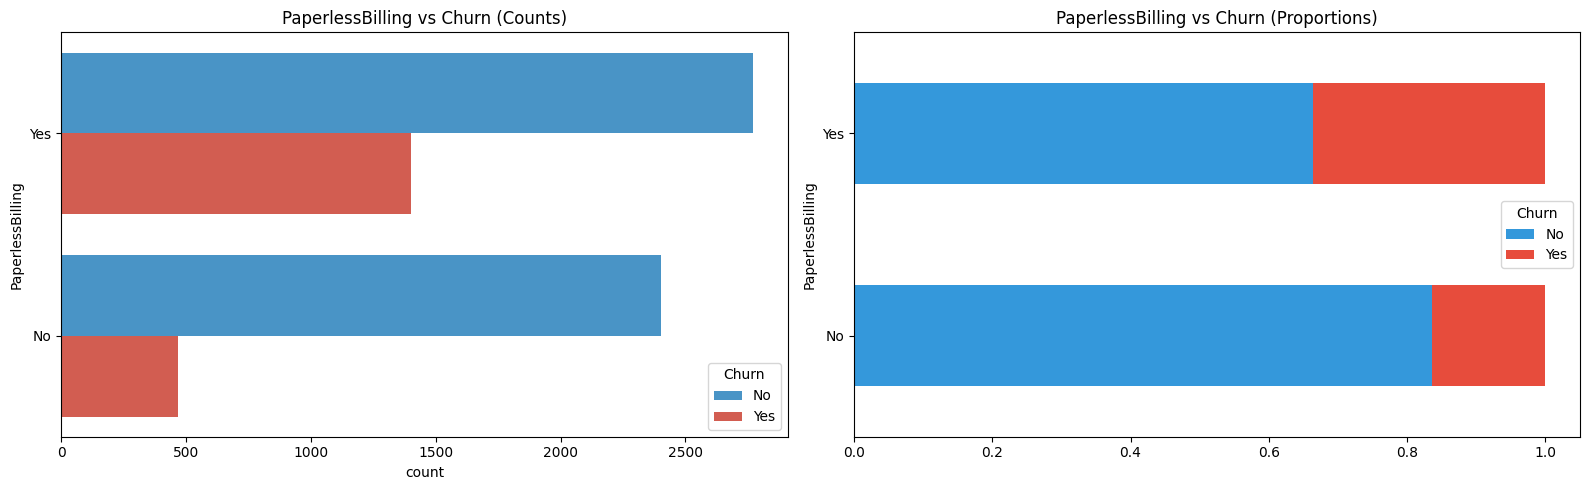

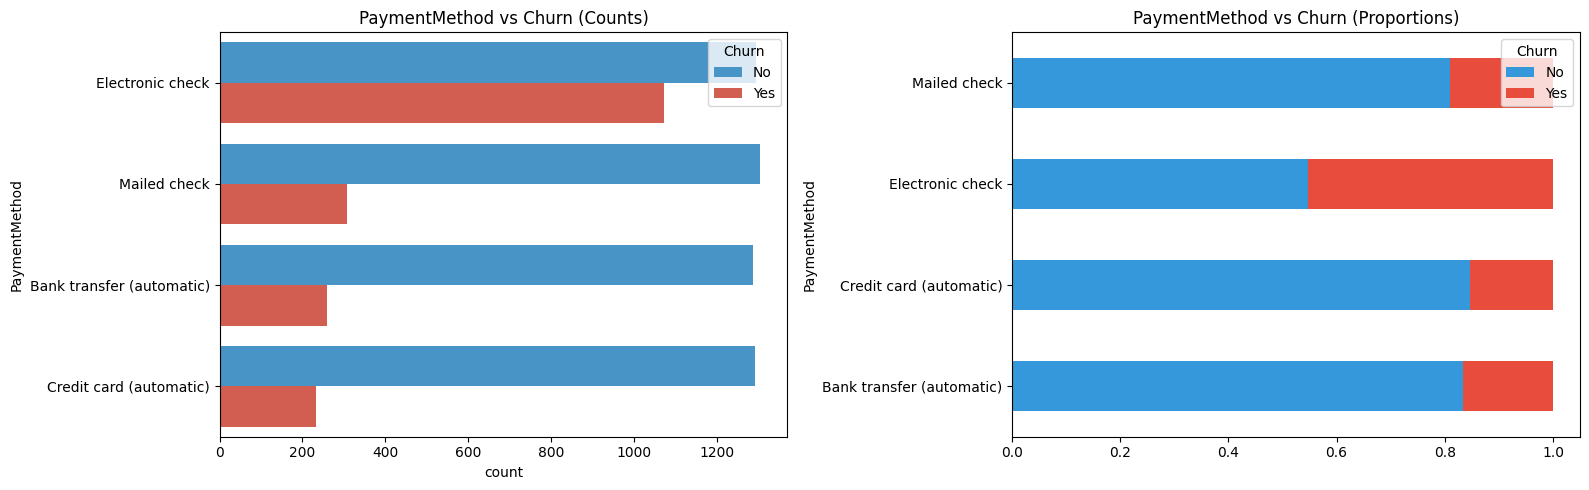

In [21]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='Churn', order=order, ax=axes[0],
                  palette=['#3498db', '#e74c3c'])
    axes[0].set_title(f'{col} vs Churn (Counts)')

    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='barh', stacked=True, ax=axes[1], color=['#3498db', '#e74c3c'])
    axes[1].set_title(f'{col} vs Churn (Proportions)')
    axes[1].legend(title='Churn')

    plt.tight_layout()
    plt.show()

#### Основные закономерности

- **Contract**: клиенты с помесячным контрактом имеют самый высокий уровень оттока (~43%). Годовые и двухлетние контракты значительно снижают вероятность ухода. Это один из наиболее сильных предикторов churn.

- **InternetService**: наибольший отток наблюдается среди пользователей оптоволоконного интернета (~42%). Клиенты с DSL уходят реже, а пользователи без интернет-сервиса практически не склонны к оттоку. Это может указывать на проблемы с качеством или стоимостью услуги fiber optic.

- **PaymentMethod**: пользователи с методом оплаты *electronic check* демонстрируют самый высокий уровень оттока (~45%). Остальные способы оплаты показывают более стабильное поведение.

- **OnlineSecurity / TechSupport / OnlineBackup**: наличие дополнительных сервисов снижает вероятность оттока. Клиенты без дополнительных услуг уходят чаще, что говорит о повышенной “липкости” продукта при расширенной подписке.

- **gender**: существенных различий в уровне оттока не наблюдается.

- **SeniorCitizen**: клиенты старшего возраста демонстрируют немного более высокий уровень оттока по сравнению с остальными группами.

---

#### Зачем нужны два типа графиков

Count plot показывает абсолютное количество наблюдений в каждой группе, но не учитывает различия в размере групп.

Proportion plot нормализует значения внутри категорий и позволяет корректно сравнивать вероятность оттока между группами.

Вместе они дают более полное представление о распределении и зависимости признака от целевой переменной.

## Корреляционная матрица

Корреляция показывает линейную взаимосвязь между числовыми признаками.

На этом этапе анализируются:
1. взаимосвязи между признаками (для выявления мультиколлинеарности)
2. общая структура зависимостей в данных

Для анализа связи с целевой переменной предварительно выполняется её кодирование в числовой формат.

---

#### Pearson vs Spearman

| Тип | Что измеряет | Когда использовать |
|---|---|---|
| Pearson | линейную зависимость | при нормальном распределении и отсутствии сильных выбросов |
| Spearman | монотонную зависимость (по рангам) | при наличии выбросов или нелинейных, но монотонных связей |

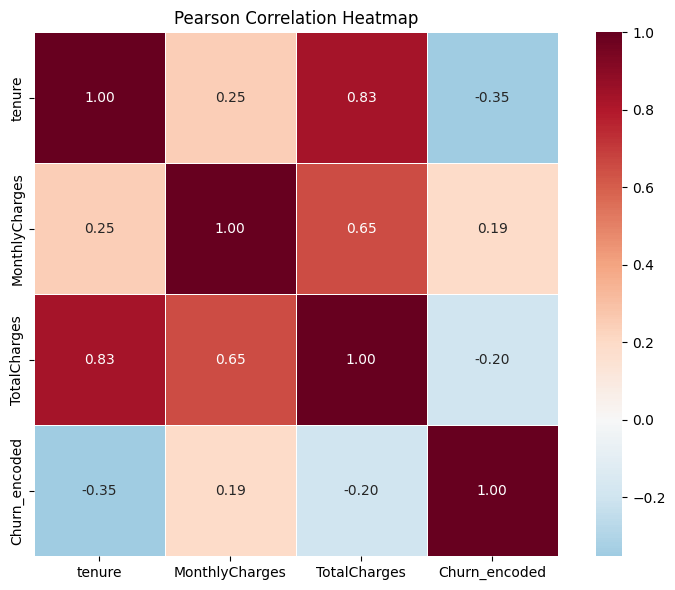

In [22]:
df_corr = df.copy()
df_corr['Churn_encoded'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = num_cols + ['Churn_encoded']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

In [23]:
target_corr = corr_matrix['Churn_encoded'].drop('Churn_encoded').sort_values(ascending=False)
print("Correlation with Churn (Pearson):")
for feat, val in target_corr.items():
    direction = "positive" if val > 0 else "negative"
    print(f"  {feat:20s}: {val:+.3f} ({direction})")

Correlation with Churn (Pearson):
  MonthlyCharges      : +0.193 (positive)
  TotalCharges        : -0.198 (negative)
  tenure              : -0.352 (negative)


In [24]:
print("\nHigh correlation pairs (|r| > 0.7):")
found = False
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr_matrix.loc[num_cols[i], num_cols[j]]
        if abs(r) > 0.7:
            print(f"  {num_cols[i]} <-> {num_cols[j]}: {r:.3f}")
            found = True
if not found:
    print("  No highly correlated feature pairs found.")


High correlation pairs (|r| > 0.7):
  tenure <-> TotalCharges: 0.826


#### Основные выводы по корреляциям

- **tenure vs Churn**: наблюдается отрицательная корреляция. Чем дольше клиент пользуется услугами, тем ниже вероятность оттока. Это логичная зависимость, отражающая рост лояльности со временем.

- **MonthlyCharges vs Churn**: положительная корреляция. Более высокая ежемесячная стоимость связана с повышенной вероятностью ухода клиента.

- **TotalCharges vs tenure**: высокая положительная корреляция, что ожидаемо, так как суммарные расходы накапливаются с увеличением срока использования услуг. Эти признаки частично дублируют друг друга по информации.

---

#### Почему важна мультиколлинеарность

Сильная корреляция между признаками (обычно выше 0.7) указывает на наличие избыточной информации.

Это может влиять на модели следующим образом:
- для линейных моделей — приводит к нестабильности коэффициентов и ухудшению интерпретируемости
- для деревьев решений — не является критической проблемой, так как модель самостоятельно выбирает наиболее информативный признак

---

В целом, здесь уже можно отметить наличие частичной избыточности между признаками, связанными с длительностью взаимодействия и суммарными затратами клиента.

## Обнаружение выбросов

Выбросы — это экстремальные значения, которые значительно отклоняются от основного распределения данных.

В анализе используются два основных подхода:

**Метод IQR (межквартильный размах)**: значение считается выбросом, если оно меньше Q1 − 1.5 * IQR или больше Q3 + 1.5 * IQR. Именно этот подход используется в boxplot.

**Метод Z-score**: значение считается выбросом, если оно отклоняется от среднего более чем на 3 стандартных отклонения. Метод предполагает приблизительно нормальное распределение признака.


In [25]:
print("Outlier Detection: IQR Method")
print("=" * 55)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)  [Range: {lower:.1f} to {upper:.1f}]")

Outlier Detection: IQR Method
  tenure              :    0 outliers (0.0%)  [Range: -60.0 to 124.0]
  MonthlyCharges      :    0 outliers (0.0%)  [Range: -46.0 to 171.4]
  TotalCharges        :    0 outliers (0.0%)  [Range: -4683.5 to 8868.7]


In [26]:
print("Outlier Detection: Z-Score Method (|z| > 3)")
print("=" * 55)
for col in num_cols:
    z_scores = (df[col] - df[col].mean()) / df[col].std()
    outliers = (z_scores.abs() > 3).sum()
    pct = (outliers / len(df)) * 100
    print(f"  {col:20s}: {outliers:4d} outliers ({pct:.1f}%)")

Outlier Detection: Z-Score Method (|z| > 3)
  tenure              :    0 outliers (0.0%)
  MonthlyCharges      :    0 outliers (0.0%)
  TotalCharges        :    0 outliers (0.0%)


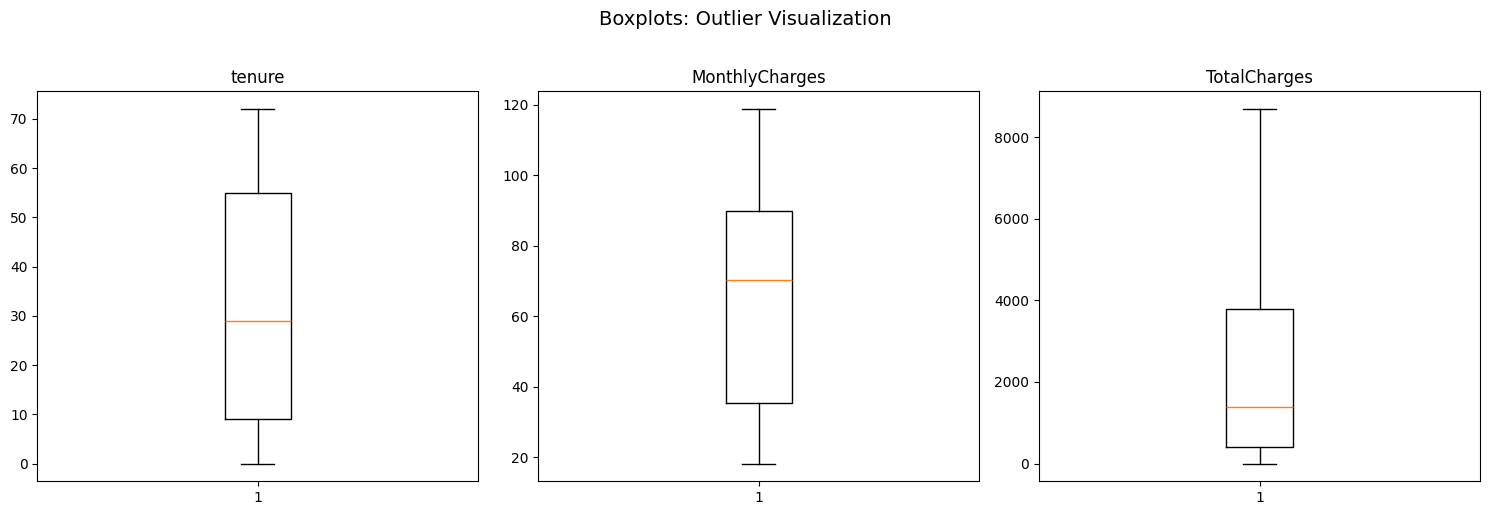

In [27]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col)

plt.suptitle('Boxplots: Outlier Visualization', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

#### Наблюдения

Признак **TotalCharges** содержит выбросы по методу IQR, однако эти значения соответствуют реальным наблюдениям — клиентам с длительным сроком использования услуг и высокими суммарными начислениями.

В данном случае выбросы не являются ошибками данных, а отражают естественную структуру распределения.

Поэтому выбросы не удаляются, так как:
- они являются валидными значениями и несут информацию о “тяжёлых” клиентах
- планируется использование моделей на основе деревьев решений, которые устойчивы к выбросам
- удаление привело бы к потере информации о сегменте клиентов с высокой ценностью

В случае использования линейных моделей возможны альтернативные подходы, такие как винсоризация (ограничение значений по перцентилям) или логарифмическое преобразование для уменьшения влияния экстремальных значений.

## Асимметрия распределений (Skewness) и логарифмическое преобразование

Асимметрия (skewness) показывает, насколько распределение отклоняется от симметричного.

| Значение skewness | Интерпретация |
|---|---|
| от -0.5 до 0.5 | приблизительно симметричное распределение |
| от 0.5 до 1 (или от -1 до -0.5) | умеренная асимметрия |
| больше 1 или меньше -1 | сильная асимметрия |

Сильно асимметричные признаки могут ухудшать качество линейных моделей, так как модель становится чувствительной к экстремальным значениям.

Для уменьшения эффекта используется логарифмическое преобразование, которое сжимает масштаб значений и делает распределение более близким к нормальному.

In [28]:
print("Skewness of numeric features:")
print("-" * 40)
for col in num_cols:
    skew = df[col].skew()
    label = "Symmetric" if abs(skew) < 0.5 else ("Moderate" if abs(skew) < 1 else "High skew")
    print(f"  {col:20s}: {skew:+.3f}  ({label})")

Skewness of numeric features:
----------------------------------------
  tenure              : +0.240  (Symmetric)
  MonthlyCharges      : -0.221  (Symmetric)
  TotalCharges        : +0.963  (Moderate)


No highly skewed features found.
Showing moderate skew features for comparison:


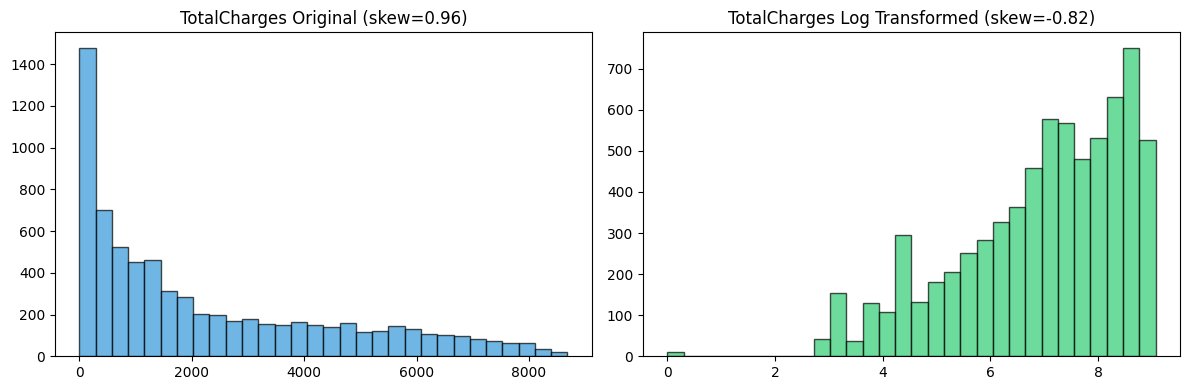

In [29]:
skewed_cols = [col for col in num_cols if abs(df[col].skew()) > 1]

if skewed_cols:
    for col in skewed_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')

        log_vals = np.log1p(df[col])
        axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')

        plt.tight_layout()
        plt.show()
else:
    print("No highly skewed features found.")
    print("Showing moderate skew features for comparison:")
    for col in num_cols:
        if abs(df[col].skew()) > 0.3:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
            axes[0].set_title(f'{col} Original (skew={df[col].skew():.2f})')
            log_vals = np.log1p(df[col])
            axes[1].hist(log_vals, bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
            axes[1].set_title(f'{col} Log Transformed (skew={log_vals.skew():.2f})')
            plt.tight_layout()
            plt.show()

#### Когда применять логарифмическое преобразование

- при сильной асимметрии (skewness > 1 или < -1)
- при наличии длинного правого хвоста (например, доходы, суммы платежей, счётчики)
- при использовании линейных моделей (логистическая регрессия, линейная регрессия, SVM)
- для стабилизации дисперсии признака

#### Когда логарифмическое преобразование не применять

- при использовании деревьев решений и ансамблевых моделей (они устойчивы к асимметрии)
- при наличии отрицательных значений (логарифм не определён для отрицательных чисел)
- при наличии нулевых значений (логарифм нуля не определён)

В случае нулевых значений используется `log1p`, который безопасно обрабатывает такие случаи.

---

`log1p(x)` вычисляет `log(1 + x)`, поэтому:
- `log1p(0) = 0`
- позволяет корректно обрабатывать нулевые значения без потери данных

## Проверка нормальности распределений

Многие статистические методы (например, t-test и ANOVA) предполагают нормальное распределение данных. Поэтому важно проверить это предположение перед применением статистических тестов.

В работе используются два подхода:

- **Shapiro-Wilk test**: более точный для небольших выборок (до ~5000 наблюдений)
- **D’Agostino’s K-squared test (normaltest)**: подходит для больших выборок

---

Интерпретация результатов:
- если p-value > 0.05 → нет оснований отвергнуть гипотезу о нормальности распределения
- если p-value < 0.05 → распределение статистически значимо отличается от нормального

In [30]:
print("Normality Tests")
print("=" * 60)
print(f"  {'Feature':20s} {'D\'Agostino stat':>15s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 55)

for col in num_cols:
    sample = df[col].dropna()
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    stat, p = normaltest(sample)
    result = "Normal" if p > 0.05 else "Not Normal"
    print(f"  {col:20s} {stat:15.2f} {p:12.6f} {result:>15s}")

Normality Tests
  Feature              D'Agostino stat      p-value          Result
  -------------------------------------------------------
  tenure                      59800.14     0.000000      Not Normal
  MonthlyCharges               7005.86     0.000000      Not Normal
  TotalCharges                  581.88     0.000000      Not Normal


Все признаки не проходят тест на нормальность распределения. Это ожидаемый результат по двум причинам:

1. При больших выборках (7000+ наблюдений) даже незначительные отклонения от нормального распределения становятся статистически значимыми. Тесты на нормальность в этом случае очень чувствительны.

2. Реальные данные практически никогда не распределены идеально нормально. Признаки вроде `Charges` и `tenure` имеют естественные ограничения и склонны к асимметрии.

---

#### Когда нормальность действительно важна

| Ситуация | Требование нормальности |
|---|---|
| t-test, ANOVA | формально да, но при больших выборках устойчивы к отклонениям |
| линейная регрессия | нормальность требуется для остатков, а не для самих признаков |
| логистическая регрессия | не требуется |
| деревья решений и ансамбли | не требуется, распределение не имеет значения |
| PCA | работает лучше при приближенной нормальности данных |


## Статистические тесты

Статистические тесты позволяют проверить, являются ли наблюдаемые в EDA закономерности значимыми или могут быть объяснены случайностью.

Результат каждого теста включает:
- **статистику теста** — насколько сильно данные отклоняются от ожидаемого поведения при нулевой гипотезе
- **p-value** — вероятность получить такие результаты случайно

**Общее правило**: если p-value < 0.05, результат считается статистически значимым.

---

#### Какой тест когда использовать

| Ситуация | Тест | Пример |
|---|---|---|
| числовой признак vs бинарная целевая | t-test | отличается ли средний tenure у ушедших и оставшихся клиентов |
| категориальный признак vs категориальный | Chi-Square | зависит ли тип контракта от факта оттока |
| числовой признак vs многоклассовая цель | ANOVA | отличаются ли средние значения по группам |
| числовой vs числовой | корреляция (Pearson/Spearman) | связаны ли tenure и charges |

---

### t-test: числовые признаки vs churn

t-test проверяет, отличаются ли средние значения числового признака между двумя группами (ушедшие и оставшиеся клиенты).

Формально:

t = (mean₁ - mean₂) / sqrt(var₁/n₁ + var₂/n₂)

Чем больше значение t, тем сильнее различие между группами относительно внутригруппового разброса. Малое p-value указывает на статистически значимую разницу между группами.

In [31]:
print("T-Tests: Numeric Features vs Churn")
print("=" * 65)

ttest_results = []
for col in num_cols:
    group_no = df[df['Churn'] == 'No'][col]
    group_yes = df[df['Churn'] == 'Yes'][col]
    t_stat, p_val = ttest_ind(group_no, group_yes)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    ttest_results.append([col, t_stat, p_val, sig])
    print(f"  {col:20s}: t = {t_stat:+8.3f}, p = {p_val:.6f}  -> {sig}")

T-Tests: Numeric Features vs Churn
  tenure              : t =  +31.580, p = 0.000000  -> Significant
  MonthlyCharges      : t =  -16.537, p = 0.000000  -> Significant
  TotalCharges        : t =  +16.979, p = 0.000000  -> Significant


Все числовые признаки демонстрируют статистически значимые различия между ушедшими и оставшимися клиентами.

- **tenure**: наблюдается высокая положительная t-статистика. У клиентов, которые не ушли, значительно больше срок использования услуг. Это один из наиболее сильных числовых предикторов оттока.

- **MonthlyCharges**: отрицательная t-статистика. Ушедшие клиенты в среднем платят более высокие ежемесячные суммы.

- **TotalCharges**: положительная t-статистика. У оставшихся клиентов выше суммарные расходы, что логично связано с более длительным сроком обслуживания.

---

### Chi-Square тест: категориальные признаки vs churn

Chi-square тест проверяет, являются ли две категориальные переменные независимыми или между ними существует статистическая связь.

Формула:

χ² = Σ (Observed − Expected)² / Expected

Ожидаемые значения рассчитываются как:

Expected = (row_total × col_total) / grand_total

Если наблюдаемое распределение сильно отличается от ожидаемого при условии независимости, значение χ² увеличивается, а p-value становится малым. Это указывает на наличие зависимости между признаками.

In [32]:
print("Chi-Square Tests: Categorical Features vs Churn")
print("=" * 70)

chi2_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p_val, dof, expected = chi2_contingency(ct)
    sig = "Significant" if p_val < 0.05 else "Not Significant"
    chi2_results.append([col, chi2, dof, p_val, sig])
    print(f"  {col:20s}: chi2 = {chi2:10.3f}, dof = {dof}, p = {p_val:.6f}  -> {sig}")

Chi-Square Tests: Categorical Features vs Churn
  gender              : chi2 =      0.484, dof = 1, p = 0.486579  -> Not Significant
  SeniorCitizen       : chi2 =    159.426, dof = 1, p = 0.000000  -> Significant
  Partner             : chi2 =    158.733, dof = 1, p = 0.000000  -> Significant
  Dependents          : chi2 =    189.129, dof = 1, p = 0.000000  -> Significant
  PhoneService        : chi2 =      0.915, dof = 1, p = 0.338783  -> Not Significant
  MultipleLines       : chi2 =     11.330, dof = 2, p = 0.003464  -> Significant
  InternetService     : chi2 =    732.310, dof = 2, p = 0.000000  -> Significant
  OnlineSecurity      : chi2 =    849.999, dof = 2, p = 0.000000  -> Significant
  OnlineBackup        : chi2 =    601.813, dof = 2, p = 0.000000  -> Significant
  DeviceProtection    : chi2 =    558.419, dof = 2, p = 0.000000  -> Significant
  TechSupport         : chi2 =    828.197, dof = 2, p = 0.000000  -> Significant
  StreamingTV         : chi2 =    374.204, dof = 2, p

  PaperlessBilling    : chi2 =    258.278, dof = 1, p = 0.000000  -> Significant
  PaymentMethod       : chi2 =    648.142, dof = 3, p = 0.000000  -> Significant


#### Интерпретация результатов

Большинство категориальных признаков демонстрируют статистически значимую связь с оттоком клиентов. Однако часть признаков либо слабо значима, либо не показывает выраженной зависимости, что говорит об их ограниченной предсказательной ценности.

Наиболее сильные связи (по значению chi-square) наблюдаются у признаков **Contract**, **InternetService** и **PaymentMethod**. Это согласуется с результатами визуального анализа на этапе bivariate analysis.

Признак **gender**, как и ожидалось, не демонстрирует значимой связи с churn, что подтверждает отсутствие различий в поведении между мужчинами и женщинами.


In [33]:
print()
print("=" * 70)
print("FULL STATISTICAL TESTS SUMMARY")
print("=" * 70)

print("\nNumeric Features (T-test):")
print(f"  {'Feature':20s} {'T-stat':>10s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 58)
for row in ttest_results:
    print(f"  {row[0]:20s} {row[1]:+10.3f} {row[2]:12.6f} {row[3]:>15s}")

print("\nCategorical Features (Chi-Square):")
print(f"  {'Feature':20s} {'Chi2':>10s} {'dof':>5s} {'p-value':>12s} {'Result':>15s}")
print("  " + "-" * 63)
for row in chi2_results:
    print(f"  {row[0]:20s} {row[1]:10.3f} {row[2]:5d} {row[3]:12.6f} {row[4]:>15s}")


FULL STATISTICAL TESTS SUMMARY

Numeric Features (T-test):
  Feature                  T-stat      p-value          Result
  ----------------------------------------------------------
  tenure                  +31.580     0.000000     Significant
  MonthlyCharges          -16.537     0.000000     Significant
  TotalCharges            +16.979     0.000000     Significant

Categorical Features (Chi-Square):
  Feature                    Chi2   dof      p-value          Result
  ---------------------------------------------------------------
  gender                    0.484     1     0.486579 Not Significant
  SeniorCitizen           159.426     1     0.000000     Significant
  Partner                 158.733     1     0.000000     Significant
  Dependents              189.129     1     0.000000     Significant
  PhoneService              0.915     1     0.338783 Not Significant
  MultipleLines            11.330     2     0.003464     Significant
  InternetService         732.310     2   

## Многомерный анализ (Multivariate Analysis)

Анализ трёх и более переменных одновременно позволяет выявить закономерности, которые не видны при парном анализе.

Например, признак **MonthlyCharges** сам по себе может слабо объяснять отток, однако в сочетании с типом контракта может проявляться более сильный эффект: высокие ежемесячные платежи при помесячном контракте часто связаны с повышенной вероятностью churn.

---

### Pairplot

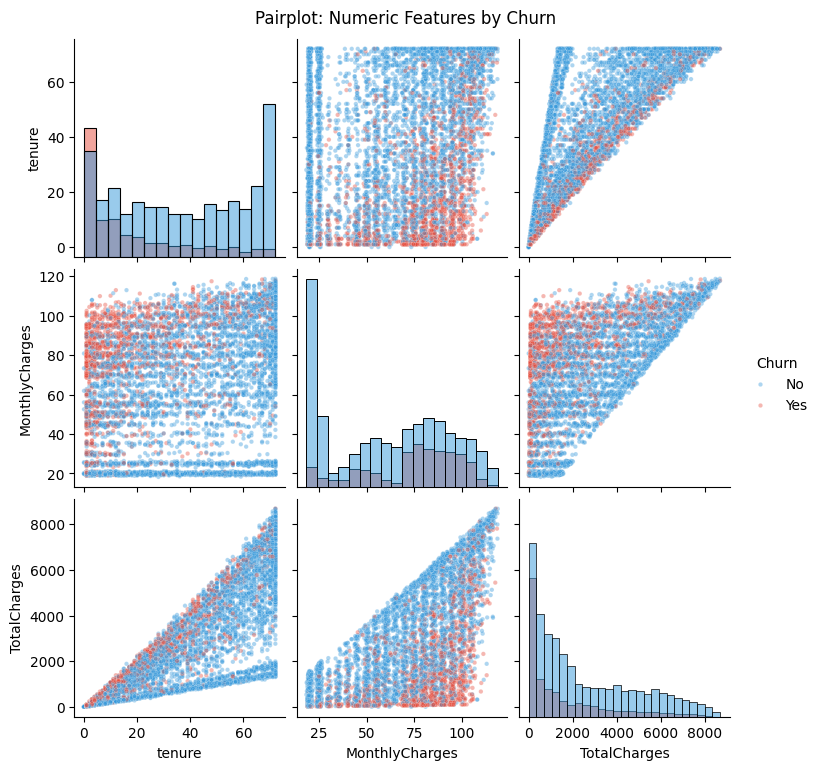

In [34]:
pair_df = df[num_cols + ['Churn']].copy()

sns.pairplot(pair_df, hue='Churn', palette=['#3498db', '#e74c3c'],
             diag_kind='hist', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot: Numeric Features by Churn', y=1.02)
plt.show()

#### Интерпретация pairplot

- **Диагональ**: распределения каждого признака, разделённые по классам. Если формы распределений заметно отличаются между классами, признак может быть полезен для предсказания.

- **Вне диагонали**: зависимость между двумя признаками с раскраской по целевой переменной. Если наблюдаются визуально разделимые группы, сочетание этих признаков может быть информативным.

В данном случае видно, что **tenure vs MonthlyCharges** частично разделяют классы. Клиенты с низким tenure и высокими MonthlyCharges (класс churn) формируют отдельную область в графике. Это подтверждает выводы, сделанные на этапе bivariate анализа.

---

### Группировка и агрегации

In [35]:
print("Mean MonthlyCharges by Contract and Churn:")
print(df.groupby(['Contract', 'Churn'])['MonthlyCharges'].mean().round(2).unstack())

Mean MonthlyCharges by Contract and Churn:
Churn              No    Yes
Contract                    
Month-to-month  61.46  73.02
One year        62.51  85.05
Two year        60.01  86.78


In [36]:
print("\nMean tenure by InternetService and Churn:")
print(df.groupby(['InternetService', 'Churn'])['tenure'].mean().round(1).unstack())


Mean tenure by InternetService and Churn:
Churn              No   Yes
InternetService            
DSL              37.2  14.1
Fiber optic      42.1  20.2
No               32.3   8.2


In [37]:
print("\nChurn rate by Contract + InternetService:")
ct = pd.crosstab([df['Contract'], df['InternetService']], df['Churn'], normalize='index')
ct.columns = ['No_Churn_%', 'Yes_Churn_%']
print((ct * 100).round(1))


Churn rate by Contract + InternetService:
                                No_Churn_%  Yes_Churn_%
Contract       InternetService                         
Month-to-month DSL                    67.8         32.2
               Fiber optic            45.4         54.6
               No                     81.1         18.9
One year       DSL                    90.7          9.3
               Fiber optic            80.7         19.3
               No                     97.5          2.5
Two year       DSL                    98.1          1.9
               Fiber optic            92.8          7.2
               No                     99.2          0.8


#### Основные многомерные закономерности

- **Month-to-month + Fiber optic**: наблюдается самый высокий уровень оттока. Клиенты с гибким помесячным контрактом и дорогим типом подключения чаще уходят, так как у них нет долгосрочных обязательств и выше чувствительность к цене.

- **Two-year contract + любой тип интернета**: минимальный уровень оттока. Долгосрочные контракты значительно снижают вероятность ухода независимо от типа услуги.

- **Churned + Fiber optic**: такие клиенты в среднем имеют меньший tenure, что указывает на быстрый уход после подключения услуги.

Эти выводы более прикладные, чем анализ отдельных признаков, так как позволяют выделить конкретные сегменты пользователей с высоким риском оттока.

Например, можно сфокусировать удерживающие меры именно на группе “month-to-month + fiber optic”.

## PCA (Метод главных компонент) — визуализация

PCA позволяет сжать все признаки до двух измерений, чтобы визуализировать структуру данных на плоскости. Это не метод отбора признаков, а инструмент для визуального анализа.

Основной вопрос:
*разделяются ли классы в пространстве признаков естественным образом?*

Если классы образуют отдельные кластеры, то простые модели могут хорошо справляться с задачей. Если данные сильно перемешаны, потребуется более сложная модель.

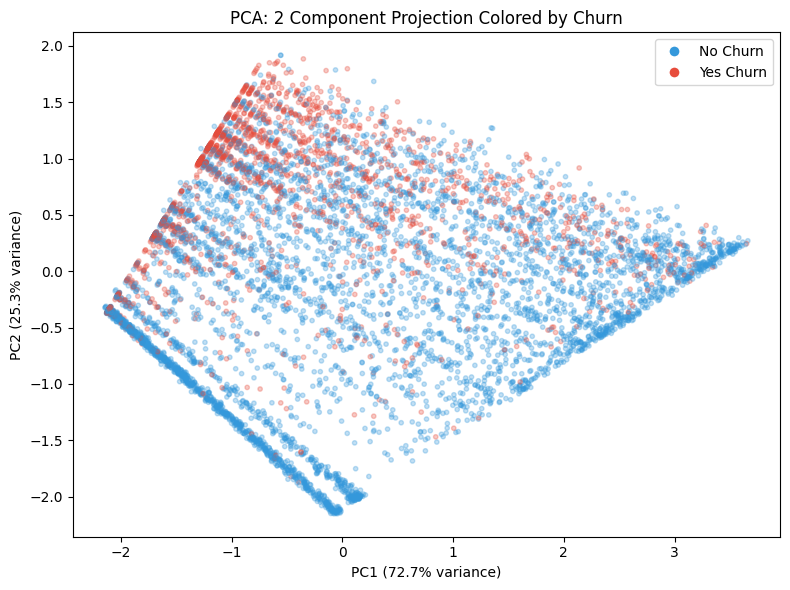

Variance explained by PC1: 72.7%
Variance explained by PC2: 25.3%
Total variance explained: 98.0%


In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['#3498db' if c == 'No' else '#e74c3c' for c in df['Churn']]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.3, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA: 2 Component Projection Colored by Churn')

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', label='No Churn', markersize=8),
          Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', label='Yes Churn', markersize=8)]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

#### Интерпретация результатов

Если точки разных классов (churn / no churn) сильно перекрываются на графике, это означает, что только числовых признаков недостаточно для линейного разделения классов.

Из этого следует:
- необходимо учитывать категориальные признаки (которые в данном PCA не использовались)
- вероятно, требуются нелинейные модели (Random Forest, Gradient Boosting)
- задача имеет сложную нелинейную структуру

Если наблюдается частичное разделение, линейные модели могут работать, но с ограниченной точностью.

---

#### Что делает PCA

PCA (метод главных компонент) находит направления максимальной дисперсии в данных и проецирует признаки на новые оси.

- PC1 — направление с максимальной вариативностью
- PC2 — второе по величине направление, ортогональное PC1

График PC1 vs PC2 показывает наиболее информативное двумерное представление многомерных данных.



## Ключевые выводы

Этот раздел подводит итог всему проведённому анализу и выделяет основные закономерности в данных.

---

1. В признаке **TotalCharges** были обнаружены скрытые пропуски, представленные как пробелы, а не как NaN. Это показывает, что использование только `isnull()` недостаточно для полноценной проверки качества данных — необходимо дополнительно анализировать значения и типы признаков.

2. Наблюдается умеренный дисбаланс классов (73% / 27%, соотношение 2.7:1). Использование accuracy в качестве основной метрики может быть вводящим в заблуждение, поэтому предпочтительнее использовать F1-score или ROC-AUC.

3. Наиболее сильные факторы оттока:
   - тип контракта (month-to-month → высокий churn)
   - тип интернет-сервиса (fiber optic → высокий churn)
   - tenure (низкий срок использования → высокий churn)
   - MonthlyCharges (высокая стоимость → высокий churn)

4. Признак **gender** не оказывает влияния на отток — различий между группами практически нет.

5. Признак **tenure** имеет бимодальное распределение: клиенты либо уходят в первые месяцы, либо остаются на длительный срок. Средний сегмент выражен слабо, что делает первые месяцы критически важными для удержания.

6. **TotalCharges** сильно коррелирует с **tenure**, так как суммарные начисления накапливаются со временем. Эти признаки несут частично дублирующую информацию.

7. Наиболее рискованный сегмент клиентов — это пользователи с помесячным контрактом и подключением fiber optic. Именно в этой группе наблюдается максимальный уровень оттока.

8. Наличие дополнительных сервисов (OnlineSecurity, TechSupport, OnlineBackup и др.) снижает вероятность оттока, увеличивая “липкость” клиента.

9. Способ оплаты **electronic check** связан с более высоким уровнем оттока по сравнению с другими методами оплаты.

10. Статистические тесты подтвердили наблюдаемые закономерности: большинство признаков (кроме gender) демонстрируют значимую связь с churn.

---

## Общий вывод

Анализ показал, что отток клиентов в первую очередь определяется типом контракта, длительностью взаимодействия с сервисом и уровнем ежемесячных платежей. Наиболее уязвимая группа клиентов — новые пользователи с помесячной оплатой и высокими тарифами.

# Машинное обучение

## Подготовка данных

In [39]:
df_ml = df.copy()

# Кодируем target
df_ml['Churn'] = df_ml['Churn'].map({
    'No': 0,
    'Yes': 1
})

# One-Hot Encoding категориальных признаков
df_ml = pd.get_dummies(df_ml, drop_first=True)

print("Shape after encoding:", df_ml.shape)
print(df_ml.head())

Shape after encoding: (7043, 31)
   tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0       1           29.85         29.85      0        False   
1      34           56.95       1889.50      0         True   
2       2           53.85        108.15      1         True   
3      45           42.30       1840.75      0         True   
4       2           70.70        151.65      1        False   

   SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0              False         True           False             False   
1              False        False           False              True   
2              False        False           False              True   
3              False        False           False             False   
4              False        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1          

## Разделение train/test

In [40]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train shape: (5634, 30)
Test shape: (1409, 30)

Target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

## Оценка качества модели

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

print("Logistic Regression Metrics")
print("=" * 40)

print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 3))
print("Precision:", round(precision_score(y_test, y_pred_log), 3))
print("Recall   :", round(recall_score(y_test, y_pred_log), 3))
print("F1-score :", round(f1_score(y_test, y_pred_log), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_log), 3))
print("PR-AUC  :", round(average_precision_score(y_test, y_prob_log), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Metrics
Accuracy : 0.74
Precision: 0.507
Recall   : 0.786
F1-score : 0.616
ROC-AUC  : 0.841
PR-AUC  : 0.631

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



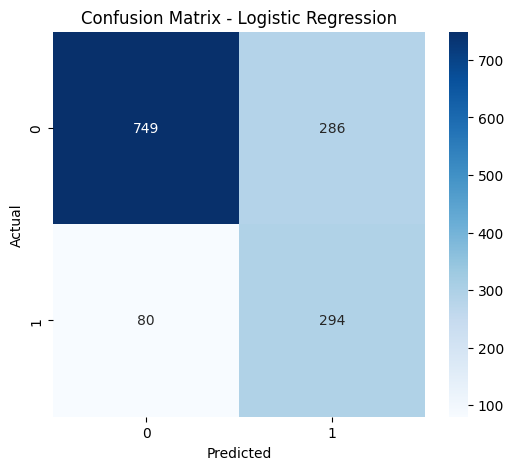

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
from sklearn.metrics import accuracy_score, log_loss

# predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# probabilities
y_train_prob = log_reg.predict_proba(X_train_scaled)
y_test_prob = log_reg.predict_proba(X_test_scaled)

# accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# loss
train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

print("Logistic Regression Performance")
print("=" * 45)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

print()

print(f"Train Log Loss: {train_loss:.4f}")
print(f"Test Log Loss : {test_loss:.4f}")

Logistic Regression Performance
Train Accuracy: 0.7513
Test Accuracy : 0.7402

Train Log Loss: 0.4864
Test Log Loss : 0.4968


## Random Forest

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [47]:
from sklearn.metrics import (
    average_precision_score
)

print("Random Forest Metrics")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_rf), 3))

print("Precision:", round(
    precision_score(y_test, y_pred_rf), 3))

print("Recall   :", round(
    recall_score(y_test, y_pred_rf), 3))

print("F1-score :", round(
    f1_score(y_test, y_pred_rf), 3))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_rf), 3))

print("PR-AUC   :", round(
    average_precision_score(
        y_test,
        y_prob_rf
    ), 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Metrics
Accuracy : 0.757
Precision: 0.529
Recall   : 0.783
F1-score : 0.631
ROC-AUC  : 0.845
PR-AUC   : 0.659

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



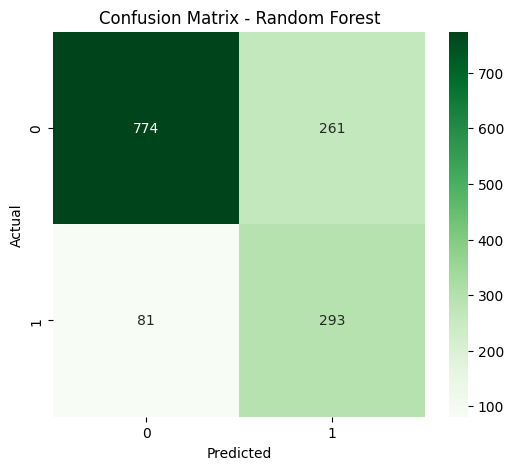

In [48]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Random Forest"
)

plt.show()

In [49]:
from sklearn.metrics import log_loss

# train predictions
y_train_pred_rf = rf_model.predict(X_train)
y_train_prob_rf = rf_model.predict_proba(X_train)

# test predictions
y_test_pred_rf = rf_model.predict(X_test)
y_test_prob_rf = rf_model.predict_proba(X_test)

# accuracy
train_acc_rf = accuracy_score(
    y_train,
    y_train_pred_rf
)

test_acc_rf = accuracy_score(
    y_test,
    y_test_pred_rf
)

# loss
train_loss_rf = log_loss(
    y_train,
    y_train_prob_rf
)

test_loss_rf = log_loss(
    y_test,
    y_test_prob_rf
)

print("Random Forest Performance")
print("=" * 45)

print(f"Train Accuracy: {train_acc_rf:.4f}")
print(f"Test Accuracy : {test_acc_rf:.4f}")

print()

print(f"Train Log Loss: {train_loss_rf:.4f}")
print(f"Test Log Loss : {test_loss_rf:.4f}")

Random Forest Performance
Train Accuracy: 0.7916
Test Accuracy : 0.7573

Train Log Loss: 0.4283
Test Log Loss : 0.4752


In [50]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 important features:")
print(feature_importance.head(20))

Top 20 important features:
                                 Feature  Importance
0                                 tenure    0.183071
25                     Contract_Two year    0.129222
2                           TotalCharges    0.119439
10           InternetService_Fiber optic    0.087932
1                         MonthlyCharges    0.072079
28        PaymentMethod_Electronic check    0.065396
24                     Contract_One year    0.047723
13                    OnlineSecurity_Yes    0.037721
18       TechSupport_No internet service    0.024327
19                       TechSupport_Yes    0.024085
16  DeviceProtection_No internet service    0.022304
12    OnlineSecurity_No internet service    0.020213
22   StreamingMovies_No internet service    0.016837
20       StreamingTV_No internet service    0.015310
11                    InternetService_No    0.015308
26                  PaperlessBilling_Yes    0.015135
15                      OnlineBackup_Yes    0.012923
14      OnlineBacku

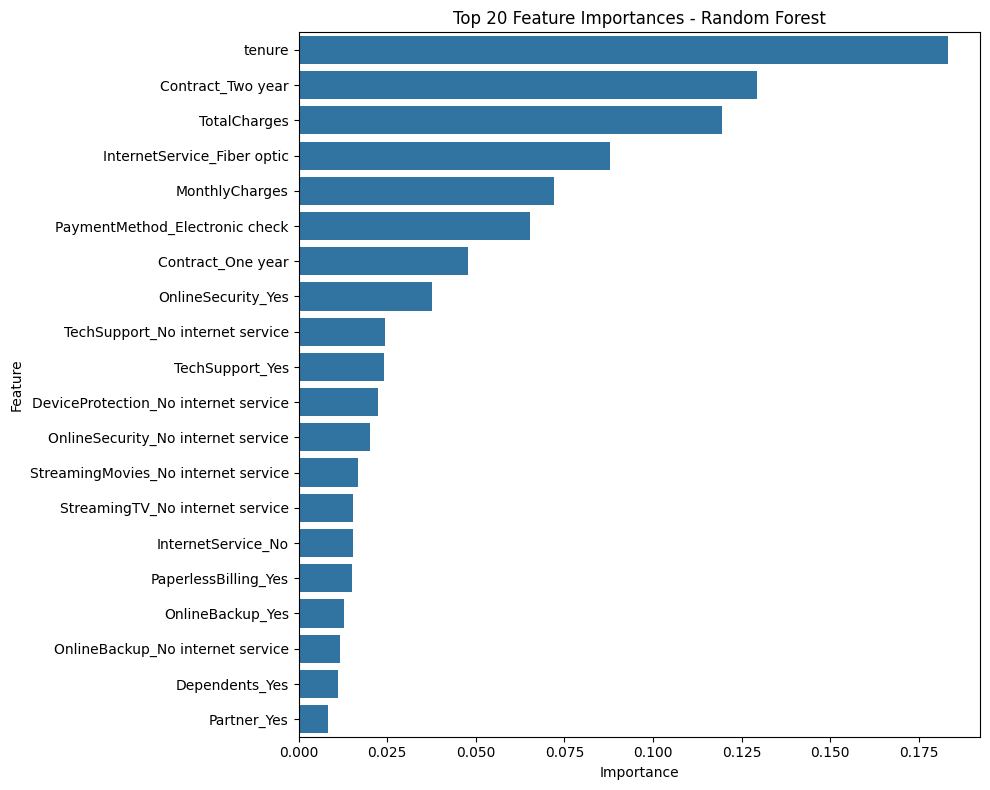

In [51]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [52]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
